<a href="https://colab.research.google.com/github/ehsankarami1358/LOKA_HYDRO/blob/main/Temperature_comp_U1_U2_U3_2026_R3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# =========================================================
# MULTI-UNIT GENERATOR THERMAL + ELECTRICAL COMPARISON
# Supports 2-unit and 3-unit comparison
# Includes useful items from your newer code:
#   - standard column mapping
#   - same MW / same MW+MVAr / same MW+MVAr+Cooling Water comparison
#   - thermal residual model per unit
#   - current per MW and field-current per MW
#   - winding sensor difference / spread
#   - unit health score
#   - pairwise comparison and 3-unit ranking
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from scipy import stats

try:
    from xgboost import XGBRegressor
    XGB_AVAILABLE = True
except Exception:
    XGB_AVAILABLE = False

In [3]:
# =========================================================
# 1. USER CONFIGURATION
# =========================================================

base = Path("/content")
output_dir = Path("MULTI_UNIT_THERMAL_ELECTRICAL_COMPARISON_OUTPUTS")
output_dir.mkdir(exist_ok=True)

# ---------------------------------------------------------
# OPTION A - If each unit has many files like your first code
# ---------------------------------------------------------
# Keep/remove units as needed.
# For 2-unit comparison, keep only UNIT1 and UNIT3, or UNIT1 and UNIT2.
# For 3-unit comparison, keep UNIT1, UNIT2, UNIT3.

UNITS = {
    "UNIT1": {
        "electric": base / "UNIT1_electric_28_4_2026_R2.csv",
        "cool":     base / "UNIT1_cool_28_4_2026_R2.csv",
        "winding1": base / "UNIT1_winding1_28_4_2026_R2.csv",
        "winding2": base / "UNIT1_winding2_28_4_2026_R2.csv",
        "core":     base / "UNIT1_Core_Pad_28_4_2026_R2.csv",
        "pad":      base / "UNIT1_Pad_Pad_28_4_2026_R2.csv",
        "air":      base / "UNIT1_Air_Pad_28_4_2026_R2.csv",
    },
    "UNIT2": {
        "electric": base / "UNIT2_electric_28_4_2026_R2.csv",
        "cool":     base / "UNIT2_cool_28_4_2026_R2.csv",
        "winding1": base / "UNIT2_winding1_28_4_2026_R2.csv",
        "winding2": base / "UNIT2_winding2_28_4_2026_R2.csv",
        "core":     base / "UNIT2_Core_Pad_28_4_2026_R2.csv",
        "pad":      base / "UNIT2_Pad_Pad_28_4_2026_R2.csv",
        "air":      base / "UNIT2_Air_Pad_28_4_2026_R2.csv",
    },
    "UNIT3": {
        "electric": base / "UNIT3_electric_28_4_2026_R2.csv",
        "cool":     base / "UNIT3_cool_28_4_2026_R2.csv",
        "winding1": base / "UNIT3_winding1_28_4_2026_R2.csv",
        "winding2": base / "UNIT3_winding2_28_4_2026_R2.csv",
        "core":     base / "UNIT3_Core_Pad_28_4_2026_R2.csv",
        "pad":      base / "UNIT3_Pad_Pad_28_4_2026_R2.csv",
        "air":      base / "UNIT3_Air_Pad_28_4_2026_R2.csv",
    },
}

# ---------------------------------------------------------
# OPTION B - If each unit has only 2 files: electrical + temp
# ---------------------------------------------------------
# If you want to use this mode, set USE_TWO_FILE_MODE = True
# and edit TWO_FILE_UNITS. Otherwise keep it False.

USE_TWO_FILE_MODE = False

TWO_FILE_UNITS = {
    "UNIT1": {
        "electrical": base / "UNIT1_electrical.csv",
        "temp":       base / "UNIT1_temp.csv",
    },
    "UNIT3": {
        "electrical": base / "UNIT3_electrical.csv",
        "temp":       base / "UNIT3_temp.csv",
    },
}


In [4]:
# =========================================================
# 2. STANDARD COLUMN MAP
# =========================================================
# The code tries to convert real plant column names into standard names.
# Add your exact column names here when needed.

COLUMN_MAP = {
    # time
    "Timestamp": "timestamp",
    "timestamp": "timestamp",
    "T": "timestamp",
    "Time": "timestamp",
    "DateTime": "timestamp",

    # electrical
    "ACTIVE POWER MEAS VALUE": "MW",
    "Active_power(MW)": "MW",
    "Active Power": "MW",
    "UNIT ACTIVE POWER": "MW",
    "MW": "MW",

    "UNIT REACTIVE POWER": "MVAr",
    "Reactive_power(Mvar)": "MVAr",
    "Reactive Power": "MVAr",
    "REACTIVE POWER MEAS VALUE": "MVAr",
    "MVAr": "MVAr",
    "MVAR": "MVAr",

    "Power Factor": "PF",
    "PF": "PF",

    "FIELD CURRENT": "FieldCurrent",
    "Field Current": "FieldCurrent",
    "FieldCurrent": "FieldCurrent",

    "FIELD VOLTAGE": "FieldVoltage",
    "Field Voltage": "FieldVoltage",
    "FieldVoltage": "FieldVoltage",

    "UNIT CURRENT PHASE A": "I_A",
    "UNIT CURRENT PHASE B": "I_B",
    "UNIT CURRENT PHASE C": "I_C",
    "Stator Current": "StatorCurrent",
    "StatorCurrent": "StatorCurrent",

    "UNIT VOLTAGE PHASE AB": "V_AB",
    "UNIT VOLTAGE PHASE BC": "V_BC",
    "UNIT VOLTAGE PHASE CA": "V_CA",

    # useful specific winding sensors from your second code
    "STATOR WINDING PHASE U2 TEMP": "Winding_U2",
    "Winding U2 Temp": "Winding_U2",
    "Winding_U2": "Winding_U2",

    "STATOR WINDING PHASE U164 TEMP": "Winding_U164",
    "Winding U164 Temp": "Winding_U164",
    "Winding_U164": "Winding_U164",

    # cooling water
    "GENERATOR COOLING WATER INLET TEMP": "CW_Inlet",
    "Cooling Water Inlet Temp": "CW_Inlet",
    "CW_Inlet": "CW_Inlet",

    "GENERATOR COOLING WATER OUTLET TEMP": "CW_Outlet",
    "Cooling Water Outlet Temp": "CW_Outlet",
    "CW_Outlet": "CW_Outlet",

    "UNIT#1 COOLING WATER FLOW": "CW_Flow",
    "UNIT#2 COOLING WATER FLOW": "CW_Flow",
    "UNIT#3 COOLING WATER FLOW": "CW_Flow",
    "COOLING WATER FLOW": "CW_Flow",
    "Cooling Water Flow": "CW_Flow",
    "CW_Flow": "CW_Flow",

    "COOLING WATER PRESSURE": "CW_Pressure",
    "Cooling Water Pressure": "CW_Pressure",
    "CW_Pressure": "CW_Pressure",

    # ambient / powerhouse air if available
    "AMBIENT TEMPERATURE": "AmbientTemp",
    "Ambient Temperature": "AmbientTemp",
    "POWERHOUSE AMBIENT TEMP": "AmbientTemp",
    "Powerhouse Ambient Temp": "AmbientTemp",
    "AmbientTemp": "AmbientTemp",
}

# Bin settings from your newer code
MW_BIN_WIDTH = 5
MVAR_BIN_WIDTH = 10
CW_BIN_WIDTH = 1.0

# Filtering limits
MW_MIN = 80
MW_MAX = 150
PF_MIN = 0.75
TEMP_MIN = 0
TEMP_MAX = 120
CW_MIN = 0
CW_MAX = 50
MERGE_TOLERANCE = "10min"
MIN_BIN_COUNT = 5

# Cooling-water flow validation limits.
# Adjust according to your plant design value.
CW_FLOW_MIN = 10          # m3/h, set lower if your unit uses smaller flow
CW_FLOW_MAX = 2000        # m3/h, set according to design
CW_DELTAT_MIN = 0.2       # °C, below this cooling index becomes unstable
CW_DELTAT_MAX = 20        # °C, above this likely sensor/flow error

# Severity thresholds, tune after seeing real plant behavior
SEVERITY = {
    "TempRise_warn": 32,
    "TempRise_alarm": 36,
    "WindingSpread_warn": 2.0,
    "WindingSpread_alarm": 4.0,
    "ResidualAbs_warn": 1.5,
    "ResidualAbs_alarm": 3.0,
    "CoolingStress_warn": 10,
    "CoolingStress_alarm": 15,
    "CurrentImbalance_warn": 2.0,
    "CurrentImbalance_alarm": 5.0,
    "WindingCoreGradient_warn": 8.0,
    "WindingCoreGradient_alarm": 12.0,
}

TIME_COL = "timestamp"

# =========================================================
# 3. ROBUST FILE READER
# =========================================================

def robust_read_csv(path):
    path = Path(path)
    if not path.exists():
        print(f"WARNING: file not found: {path}")
        return pd.DataFrame(columns=[TIME_COL])

    attempts = [
        {"encoding": "utf-16", "sep": "\t", "engine": "python"},
        {"encoding": "utf-16", "sep": ",",  "engine": "python"},
        {"encoding": "latin1", "sep": None, "engine": "python"},
        {"encoding": "latin1", "sep": ","},
        {"encoding": "utf-8-sig", "sep": None, "engine": "python"},
        {"encoding": "utf-8", "sep": None, "engine": "python"},
    ]

    for opt in attempts:
        try:
            df = pd.read_csv(path, **opt)
            print(f"Read OK: {path.name}, shape={df.shape}")
            return clean_raw_columns(df)
        except Exception:
            pass

    print(f"WARNING: could not read {path.name}")
    return pd.DataFrame(columns=[TIME_COL])


def clean_raw_columns(df):
    df = df.copy()
    df.columns = df.columns.astype(str).str.replace("\x00", "", regex=False).str.strip()
    df = df.loc[:, ~df.columns.str.contains("^Unnamed", regex=True)]

    # Fix BOM-like timestamp names
    df = df.rename(columns={
        "ÿþTimestamp": "Timestamp",
        "ÿþT": "Timestamp",
    })
    return df


def standardize_columns(df):
    df = clean_raw_columns(df)
    df = df.rename(columns=COLUMN_MAP)

    if TIME_COL not in df.columns:
        possible = [c for c in df.columns if "time" in c.lower() or "date" in c.lower()]
        if possible:
            df = df.rename(columns={possible[0]: TIME_COL})

    if TIME_COL in df.columns:
        df[TIME_COL] = pd.to_datetime(df[TIME_COL], errors="coerce")
        df = df.dropna(subset=[TIME_COL]).sort_values(TIME_COL).reset_index(drop=True)

    for c in df.columns:
        if c != TIME_COL:
            df[c] = pd.to_numeric(df[c], errors="coerce")

    return df

In [5]:
# =========================================================
# 4. SENSOR DETECTION
# =========================================================

def detect_columns(df):
    cols_upper = {c: c.upper() for c in df.columns}

    # Generic stator winding sensors: keep all, including Winding_U2/U164 if standardized
    winding_cols = []
    for c in df.columns:
        cu = cols_upper[c]
        if ("STATOR WINDING" in cu and "TEMP" in cu) or c.startswith("Winding_"):
            winding_cols.append(c)

    core_cols = [c for c in df.columns if "STATOR" in cols_upper[c] and "CORE" in cols_upper[c] and "TEMP" in cols_upper[c]]

    upper_bearing_cols = [c for c in df.columns if "UPPER" in cols_upper[c] and "BEARING" in cols_upper[c] and "TEMP" in cols_upper[c]]
    lower_bearing_cols = [c for c in df.columns if "LOWER" in cols_upper[c] and "BEARING" in cols_upper[c] and "TEMP" in cols_upper[c]]
    thrust_bearing_cols = [c for c in df.columns if "THRUST" in cols_upper[c] and "BEARING" in cols_upper[c] and "TEMP" in cols_upper[c]]
    bearing_cols = list(dict.fromkeys(upper_bearing_cols + lower_bearing_cols + thrust_bearing_cols))

    hot_air_cols = [c for c in df.columns if "HOT AIR" in cols_upper[c]]
    cold_air_cols = [c for c in df.columns if "COLD AIR" in cols_upper[c]]

    return {
        "winding_cols": winding_cols,
        "core_cols": core_cols,
        "bearing_cols": bearing_cols,
        "upper_bearing_cols": upper_bearing_cols,
        "lower_bearing_cols": lower_bearing_cols,
        "thrust_bearing_cols": thrust_bearing_cols,
        "hot_air_cols": hot_air_cols,
        "cold_air_cols": cold_air_cols,
    }


In [6]:
# =========================================================
# 5. LOAD EACH UNIT
# =========================================================

def load_multi_file_unit(unit_name, file_dict):
    print(f"\nLoading multi-file data for {unit_name}")
    dfs = {}
    for key, path in file_dict.items():
        dfs[key] = standardize_columns(robust_read_csv(path))

    if "electric" not in dfs or dfs["electric"].empty:
        raise ValueError(f"{unit_name}: electric file missing or empty")

    df = dfs["electric"].copy().sort_values(TIME_COL)

    for key in ["cool", "winding1", "winding2", "core", "pad", "air"]:
        if key in dfs and not dfs[key].empty and TIME_COL in dfs[key].columns:
            df = pd.merge_asof(
                df.sort_values(TIME_COL),
                dfs[key].sort_values(TIME_COL),
                on=TIME_COL,
                direction="nearest",
                tolerance=pd.Timedelta(MERGE_TOLERANCE),
                suffixes=("", f"_{key}")
            )

    return df


def load_two_file_unit(unit_name, file_dict):
    print(f"\nLoading two-file data for {unit_name}")
    elec = standardize_columns(robust_read_csv(file_dict["electrical"]))
    temp = standardize_columns(robust_read_csv(file_dict["temp"]))

    if elec.empty or temp.empty:
        raise ValueError(f"{unit_name}: electrical or temp file is empty")

    # merge_asof is usually better than outer merge for historian data with small timestamp differences
    df = pd.merge_asof(
        elec.sort_values(TIME_COL),
        temp.sort_values(TIME_COL),
        on=TIME_COL,
        direction="nearest",
        tolerance=pd.Timedelta(MERGE_TOLERANCE),
        suffixes=("", "_temp")
    )
    return df

In [18]:
import pandas as pd
import numpy as np

# =========================================================
# 6. PREPROCESS + FEATURE ENGINEERING
# =========================================================

def preprocess_unit(df, unit_name):
    df = standardize_columns(df)
    df = df.copy()

    required_base = [TIME_COL, "MW", "MVAr"]
    missing = [c for c in required_base if c not in df.columns]
    if missing:
        raise ValueError(f"{unit_name}: missing required columns: {missing}")

    sensors = detect_columns(df)
    winding_cols = sensors["winding_cols"]
    core_cols = sensors["core_cols"]
    bearing_cols = sensors["bearing_cols"]
    hot_air_cols = sensors["hot_air_cols"]
    cold_air_cols = sensors["cold_air_cols"]

    if len(winding_cols) == 0:
        raise ValueError(f"{unit_name}: no winding temperature sensors detected")

    # Power factor
    if "PF" not in df.columns:
        df["PF"] = df["MW"] / np.sqrt(df["MW"] ** 2 + df["MVAr"] ** 2)
    df["PF"] = pd.to_numeric(df["PF"], errors="coerce")

    # Stator current logic
    phase_current_cols = [c for c in ["I_A", "I_B", "I_C"] if c in df.columns]
    if len(phase_current_cols) >= 3:
        df["StatorCurrent"] = df[phase_current_cols].mean(axis=1)
        df["I_max"] = df[phase_current_cols].max(axis=1)
        df["I_min"] = df[phase_current_cols].min(axis=1)
        df["Current_Imbalance_pct"] = np.where(
            df["StatorCurrent"] != 0,
            (df["I_max"] - df["I_min"]) / df["StatorCurrent"] * 100,
            np.nan
        )
    elif "StatorCurrent" not in df.columns:
        df["StatorCurrent"] = np.nan
        df["Current_Imbalance_pct"] = np.nan

    # Voltage imbalance
    phase_voltage_cols = [c for c in ["V_AB", "V_BC", "V_CA"] if c in df.columns]
    if len(phase_voltage_cols) >= 3:
        df["V_mean"] = df[phase_voltage_cols].mean(axis=1)
        df["V_max"] = df[phase_voltage_cols].max(axis=1)
        df["V_min"] = df[phase_voltage_cols].min(axis=1)
        df["Voltage_Imbalance_pct"] = np.where(
            df["V_mean"] != 0,
            (df["V_max"] - df["V_min"]) / df["V_mean"] * 100,
            np.nan
        )
    else:
        df["Voltage_Imbalance_pct"] = np.nan

    if "FieldCurrent" not in df.columns:
        df["FieldCurrent"] = np.nan
    if "FieldVoltage" not in df.columns:
        df["FieldVoltage"] = np.nan
    if "CW_Inlet" not in df.columns:
        df["CW_Inlet"] = np.nan
    if "CW_Outlet" not in df.columns:
        df["CW_Outlet"] = np.nan
    if "CW_Flow" not in df.columns:
        df["CW_Flow"] = np.nan
    if "CW_Pressure" not in df.columns:
        df["CW_Pressure"] = np.nan
    if "AmbientTemp" not in df.columns:
        df["AmbientTemp"] = np.nan

    # Basic filtering
    df = df.dropna(subset=["MW", "MVAr", "PF"]).copy()
    df = df[(df["MW"] >= MW_MIN) & (df["MW"] <= MW_MAX)].copy()
    df = df[df["PF"].abs() >= PF_MIN].copy()

    # Remove impossible temperatures only from detected thermal columns
    temp_cols = list(dict.fromkeys(winding_cols + core_cols + bearing_cols + hot_air_cols + cold_air_cols + ["CW_Inlet", "CW_Outlet"]))
    for c in temp_cols:
        if c in df.columns:
            df.loc[~df[c].between(TEMP_MIN, TEMP_MAX), c] = np.nan

    if "CW_Inlet" in df.columns:
        df = df[df["CW_Inlet"].between(CW_MIN, CW_MAX) | df["CW_Inlet"].isna()].copy()

    # Remove sudden MW jump rows for stable thermal comparison
    df = df.sort_values(TIME_COL).reset_index(drop=True)
    df["MW_diff_abs"] = df["MW"].diff().abs()
    df = df[df["MW_diff_abs"].fillna(0) < 15].copy()

    # Thermal features
    df["MeanWindingTemp"] = df[winding_cols].mean(axis=1)
    df["Winding_Max"] = df[winding_cols].max(axis=1)
    df["Winding_Min"] = df[winding_cols].min(axis=1)
    df["WindingSpread"] = df["Winding_Max"] - df["Winding_Min"]
    df["WindingStd"] = df[winding_cols].std(axis=1)
    # Robust hotspot sensor detection to handle all-NaN rows
    df["HotspotSensor"] = df[winding_cols].apply(lambda x: x.idxmax() if x.notna().any() else np.nan, axis=1)

    # If U2 and U164 exist, calculate exact difference from your newer code.
    # Otherwise use max-min spread.
    if "Winding_U2" in df.columns and "Winding_U164" in df.columns:
        df["WindingDiff_U2_U164"] = (df["Winding_U2"] - df["Winding_U164"]).abs()
    else:
        df["WindingDiff_U2_U164"] = np.nan

    df["WindingDiff"] = df["WindingDiff_U2_U164"].fillna(df["WindingSpread"])

    if core_cols:
        df["Core_Avg"] = df[core_cols].mean(axis=1)
        df["Core_Max"] = df[core_cols].max(axis=1)
        df["Core_Spread"] = df[core_cols].max(axis=1) - df[core_cols].min(axis=1)
    else:
        df["Core_Avg"] = np.nan
        df["Core_Max"] = np.nan
        df["Core_Spread"] = np.nan

    if bearing_cols:
        df["Bearing_Avg"] = df[bearing_cols].mean(axis=1)
        df["Bearing_Max"] = df[bearing_cols].max(axis=1)
    else:
        df["Bearing_Avg"] = np.nan
        df["Bearing_Max"] = np.nan

    df["Hot_Air_Avg"] = df[hot_air_cols].mean(axis=1) if hot_air_cols else np.nan
    df["Cold_Air_Avg"] = df[cold_air_cols].mean(axis=1) if cold_air_cols else np.nan
    df["Air_DeltaT"] = df["Hot_Air_Avg"] - df["Cold_Air_Avg"]

    df["CW_DeltaT"] = df["CW_Outlet"] - df["CW_Inlet"]

    # -----------------------------------------------------
    # Electrical features that need StatorCurrent for I2_proxy
    # -----------------------------------------------------
    # Define I2_proxy here, before it's used in TempRise_per_I2 and ElectricalStressIndex
    df["I2_proxy"] = df["StatorCurrent"] ** 2

    # -----------------------------------------------------
    # Cooling-water flow validation
    # -----------------------------------------------------
    # Cooling flow may have wrong unit, bad scaling, or bad sensor spikes.
    # We flag invalid rows and use validated flow for cooling-efficiency KPIs.
    df["CW_Flow_Raw"] = df["CW_Flow"]
    df["CW_Flow_ValidFlag"] = (
        df["CW_Flow"].between(CW_FLOW_MIN, CW_FLOW_MAX) &
        df["CW_DeltaT"].between(CW_DELTAT_MIN, CW_DELTAT_MAX)
    )

    df["CW_Flow_Valid"] = df["CW_Flow"].where(df["CW_Flow_ValidFlag"])
    df["CW_DeltaT_Valid"] = df["CW_DeltaT"].where(df["CW_Flow_ValidFlag"])

    df["CW_Flow_kg_s"] = df["CW_Flow_Valid"] * 1000 / 3600
    df["Cooling_Heat_Removal_kW"] = df["CW_Flow_kg_s"] * 4.186 * df["CW_DeltaT_Valid"]

    df["TempRise"] = df["MeanWindingTemp"] - df["CW_Inlet"]
    df["TempRise_Max"] = df["Winding_Max"] - df["CW_Inlet"]
    df["CoolingIndex"] = df["TempRise"] / df["MW"].replace(0, np.nan)
    df["Cooling_kW_per_MW"] = df["Cooling_Heat_Removal_kW"] / df["MW"].replace(0, np.nan)

    # -----------------------------------------------------
    # Cooling efficiency / cooling effectiveness KPIs
    # -----------------------------------------------------
    # Lower values are generally better for these indexes:
    #   TempRise_per_MW: how much winding rises per MW
    #   TempRise_per_I2: separates temperature rise from stator copper loading
    #   TempRise_per_HeatRemoval: shows whether heat exchanger / cooling path is effective
    # Higher Cooling_Heat_Removal_kW_per_TempRise means better heat extraction per °C rise.

    df["TempRise_per_MW"] = df["TempRise"] / df["MW"].replace(0, np.nan)
    df["TempRise_per_I2"] = df["TempRise"] / df["I2_proxy"].replace(0, np.nan)
    df["TempRise_per_FieldCurrent"] = df["TempRise"] / df["FieldCurrent"].replace(0, np.nan)
    df["HeatRemoval_per_TempRise"] = df["Cooling_Heat_Removal_kW"] / df["TempRise"].replace(0, np.nan)
    df["HeatRemoval_per_MW"] = df["Cooling_Heat_Removal_kW"] / df["MW"].replace(0, np.nan)

    # Practical cooling performance index:
    # higher CoolingPerformanceIndex means more heat is removed with less temp rise.
    df["CoolingPerformanceIndex"] = df["HeatRemoval_per_TempRise"] / df["MW"].replace(0, np.nan)

    # If CW flow is missing, use proxy indexes only.
    # CoolingStressIndex does not need flow; higher means worse cooling/thermal condition.
    df["CoolingStressIndex"] = df["TempRise"] / df["CW_DeltaT_Valid"].replace(0, np.nan)

    # -----------------------------------------------------
    # Winding-to-core thermal gradient
    # -----------------------------------------------------
    # Higher value means winding is becoming hotter relative to stator core.
    # Useful for separating winding/copper-loss issue from general machine heating.
    df["WindingCoreGradient"] = df["MeanWindingTemp"] - df["Core_Avg"]
    df["WindingCoreGradient_Max"] = df["Winding_Max"] - df["Core_Avg"]

    # Ambient corrected temperature if ambient exists.
    df["TempRise_vs_Ambient"] = df["MeanWindingTemp"] - df["AmbientTemp"]

    # Electrical features
    df["MVA"] = np.sqrt(df["MW"] ** 2 + df["MVAr"] ** 2)
    df["PF_abs"] = df["MW"].abs() / df["MVA"].replace(0, np.nan)
    df["PF_dev"] = 1 - df["PF_abs"]
    df["MVAr_abs"] = df["MVAr"].abs()

    df["Current_per_MW"] = df["StatorCurrent"] / df["MW"].replace(0, np.nan)
    df["FieldCurrent_per_MW"] = df["FieldCurrent"] / df["MW"].replace(0, np.nan)
    df["FieldCurrent_per_MVAr_abs"] = df["FieldCurrent"] / df["MVAr_abs"].replace(0, np.nan)
    # df["I2_proxy"] = df["StatorCurrent"] ** 2 # Moved this line up
    df["ElectricalStressIndex"] = df["I2_proxy"] * df["FieldCurrent"] * df["PF_dev"].fillna(0)

    med_stress = df["ElectricalStressIndex"].median()
    df["ElectricalStressIndex_Norm"] = df["ElectricalStressIndex"] / med_stress if pd.notna(med_stress) and med_stress != 0 else np.nan

    # Bins from your newer code
    df["MW_bin"] = np.floor(df["MW"] / MW_BIN_WIDTH) * MW_BIN_WIDTH
    df["MVAr_bin"] = np.floor(df["MVAr"] / MVAR_BIN_WIDTH) * MVAR_BIN_WIDTH
    df["CW_bin"] = np.floor(df["CW_Inlet"] / CW_BIN_WIDTH) * CW_BIN_WIDTH

    # -----------------------------------------------------
    # Dynamic / lag features
    # -----------------------------------------------------
    # Generator winding temperature has thermal inertia.
    # Current MW, MVAr and cooling water do not fully explain temperature.
    # Previous temperature and previous loading are very important.

    df = df.sort_values(TIME_COL).reset_index(drop=True)

    for lag in [1, 2, 3, 6, 12]:
        df[f"MeanWindingTemp_lag{lag}"] = df["MeanWindingTemp"].shift(lag)
        df[f"TempRise_lag{lag}"] = df["TempRise"].shift(lag)
        df[f"MW_lag{lag}"] = df["MW"].shift(lag)
        df[f"MVAr_lag{lag}"] = df["MVAr"].shift(lag)
        df[f"StatorCurrent_lag{lag}"] = df["StatorCurrent"].shift(lag)
        df[f"FieldCurrent_lag{lag}"] = df["FieldCurrent"].shift(lag)
        df[f"CW_Inlet_lag{lag}"] = df["CW_Inlet"].shift(lag)

    # Exponential moving averages approximate thermal memory.
    # span=6 and 12 are useful for 1-min or few-min historian data.
    df["MW_ewm6"] = df["MW"].ewm(span=6, adjust=False).mean().shift(1)
    df["MW_ewm12"] = df["MW"].ewm(span=12, adjust=False).mean().shift(1)
    df["MVAr_ewm6"] = df["MVAr"].ewm(span=6, adjust=False).mean().shift(1)
    df["StatorCurrent_ewm6"] = df["StatorCurrent"].ewm(span=6, adjust=False).mean().shift(1)
    df["FieldCurrent_ewm6"] = df["FieldCurrent"].ewm(span=6, adjust=False).mean().shift(1)
    df["TempRise_ewm6"] = df["TempRise"].ewm(span=6, adjust=False).mean().shift(1)
    df["TempRise_ewm12"] = df["TempRise"].ewm(span=12, adjust=False).mean().shift(1)

    # Rate-of-change features detect transients.
    df["dMW"] = df["MW"].diff()
    df["dMVAr"] = df["MVAr"].diff()
    df["dStatorCurrent"] = df["StatorCurrent"].diff()
    df["dFieldCurrent"] = df["FieldCurrent"].diff()
    df["dCW_Inlet"] = df["CW_Inlet"].diff()

    df["Unit"] = unit_name
    df = df.dropna(subset=["MeanWindingTemp", "TempRise"]).copy()
    df = df.sort_values(TIME_COL).reset_index(drop=True)

    print(
        f"{unit_name}: rows={len(df)}, winding_sensors={len(winding_cols)}, "
        f"MW={df['MW'].mean():.1f}, TempRise={df['TempRise'].mean():.2f}"
    )

    return df

In [8]:
# =========================================================
# 7. THERMAL MODEL PER UNIT
# =========================================================

def build_core_temperature_model(df):
    """Separate model for stator core temperature if core sensors are available."""
    if "Core_Avg" not in df.columns or df["Core_Avg"].isna().all():
        result = df.copy()
        result["PredCoreTemp"] = np.nan
        result["ResidualCoreTemp"] = np.nan
        metrics = {"Core_R2": np.nan, "Core_MAE": np.nan, "Core_ResidualStd": np.nan, "Core_Model": "No core data"}
        return result, metrics

    candidate_features = [
        "MW", "MVAr", "PF_abs", "StatorCurrent", "FieldCurrent", "CW_Inlet",
        "AmbientTemp", "Current_per_MW", "FieldCurrent_per_MW",
        "MW_ewm6", "MVAr_ewm6", "StatorCurrent_ewm6", "FieldCurrent_ewm6",
        "dMW", "dMVAr", "dStatorCurrent", "dFieldCurrent"
    ]
    features = [c for c in candidate_features if c in df.columns and not df[c].isna().all()]
    model_df = df.dropna(subset=["Core_Avg"]).copy()
    for c in features:
        model_df[c] = model_df[c].ffill()
    model_df = model_df.dropna(subset=features + ["Core_Avg"])

    if len(model_df) < 30 or len(features) < 3:
        result = df.copy()
        result["PredCoreTemp"] = np.nan
        result["ResidualCoreTemp"] = np.nan
        metrics = {"Core_R2": np.nan, "Core_MAE": np.nan, "Core_ResidualStd": np.nan, "Core_Model": "Not enough core data"}
        return result, metrics

    X = model_df[features]
    y = model_df["Core_Avg"]
    model = RandomForestRegressor(n_estimators=250, max_depth=10, min_samples_leaf=5, random_state=42, n_jobs=-1)
    model.fit(X, y)
    pred = model.predict(X)
    residual = y - pred

    result = df.copy()
    result["PredCoreTemp"] = np.nan
    result["ResidualCoreTemp"] = np.nan
    result.loc[model_df.index, "PredCoreTemp"] = pred
    result.loc[model_df.index, "ResidualCoreTemp"] = residual

    metrics = {
        "Core_R2": r2_score(y, pred),
        "Core_MAE": mean_absolute_error(y, pred),
        "Core_ResidualStd": residual.std(),
        "Core_Model": "RandomForest",
    }
    return result, metrics


def build_thermal_model(df):
    # Predict mean winding temp from operating/electrical/cooling conditions.
    # Residual = actual - predicted.
    candidate_features = [
        # Static operating condition features
        "MW", "MVAr", "PF_abs", "FieldCurrent", "StatorCurrent", "CW_Inlet",
        "Current_per_MW", "FieldCurrent_per_MW", "Current_Imbalance_pct",
        "Voltage_Imbalance_pct", "Air_DeltaT", "CW_DeltaT",

        # Dynamic lag features: thermal inertia / delayed response
        "MeanWindingTemp_lag1", "MeanWindingTemp_lag2", "MeanWindingTemp_lag3",
        "MeanWindingTemp_lag6", "MeanWindingTemp_lag12",
        "TempRise_lag1", "TempRise_lag2", "TempRise_lag3",
        "TempRise_lag6", "TempRise_lag12",
        "MW_lag1", "MW_lag2", "MW_lag3", "MW_lag6", "MW_lag12",
        "MVAr_lag1", "MVAr_lag2", "MVAr_lag3", "MVAr_lag6", "MVAr_lag12",
        "StatorCurrent_lag1", "StatorCurrent_lag2", "StatorCurrent_lag3",
        "StatorCurrent_lag6", "StatorCurrent_lag12",
        "FieldCurrent_lag1", "FieldCurrent_lag2", "FieldCurrent_lag3",
        "FieldCurrent_lag6", "FieldCurrent_lag12",
        "CW_Inlet_lag1", "CW_Inlet_lag2", "CW_Inlet_lag3", "CW_Inlet_lag6", "CW_Inlet_lag12",
        "AmbientTemp",

        # Thermal memory features
        "MW_ewm6", "MW_ewm12", "MVAr_ewm6", "StatorCurrent_ewm6",
        "FieldCurrent_ewm6", "TempRise_ewm6", "TempRise_ewm12",

        # Transient features
        "dMW", "dMVAr", "dStatorCurrent", "dFieldCurrent", "dCW_Inlet",
    ]
    features = [c for c in candidate_features if c in df.columns and not df[c].isna().all()]

    model_df = df.dropna(subset=["MeanWindingTemp"]).copy()

    # Do NOT use backward fill for dynamic model if you want strict time-causal behavior.
    # Forward-fill is acceptable for occasional missing historian values.
    for c in features:
        model_df[c] = model_df[c].ffill()

    # Drop first rows where lag values are naturally missing.
    model_df = model_df.dropna(subset=features + ["MeanWindingTemp"])

    if len(model_df) < 30 or len(features) < 3:
        result = df.copy()
        result["PredTemp"] = np.nan
        result["ResidualTemp"] = np.nan
        metrics = {
            "R2": np.nan,
            "MAE": np.nan,
            "ResidualMean": np.nan,
            "ResidualStd": np.nan,
            "ResidualP95Abs": np.nan,
            "BestModel": "Not enough data",
        }
        return result, metrics

    X = model_df[features]
    y = model_df["MeanWindingTemp"]

    models = {
        "LinearRegression": LinearRegression(),
        "RandomForest": RandomForestRegressor(
            n_estimators=300,
            max_depth=10,
            min_samples_leaf=5,
            random_state=42,
            n_jobs=-1
        )
    }

    if XGB_AVAILABLE:
        models["XGBoost"] = XGBRegressor(
            n_estimators=300,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.85,
            colsample_bytree=0.85,
            random_state=42,
            objective="reg:squarederror"
        )

    rows = []
    preds = {}
    for name, model in models.items():
        model.fit(X, y)
        pred = model.predict(X)
        residual = y - pred
        rows.append({
            "Model": name,
            "R2": r2_score(y, pred),
            "MAE": mean_absolute_error(y, pred),
            "RMSE": np.sqrt(mean_squared_error(y, pred)),
            "ResidualMean": residual.mean(),
            "ResidualStd": residual.std(),
            "ResidualP95Abs": np.percentile(np.abs(residual), 95),
        })
        preds[name] = pred

    metrics_df = pd.DataFrame(rows).sort_values("MAE")
    best = metrics_df.iloc[0]
    best_model = best["Model"]

    result = df.copy()
    result["PredTemp"] = np.nan
    result["ResidualTemp"] = np.nan
    result.loc[model_df.index, "PredTemp"] = preds[best_model]
    result.loc[model_df.index, "ResidualTemp"] = model_df["MeanWindingTemp"] - preds[best_model]

    metrics = {
        "R2": best["R2"],
        "MAE": best["MAE"],
        "ResidualMean": best["ResidualMean"],
        "ResidualStd": best["ResidualStd"],
        "ResidualP95Abs": best["ResidualP95Abs"],
        "BestModel": best_model,
    }
    return result, metrics

In [9]:
# =========================================================
# 8. KPI SUMMARY AND HEALTH SCORE
# =========================================================

def compute_health_score(summary):
    # Higher is better.
    # These are practical relative thresholds. You can tune them later.
    score = 100.0

    # Thermal penalties
    score -= 2.0 * max(0, summary.get("Mean Temp Rise", np.nan) - 22)
    score -= 10.0 * max(0, summary.get("Std Thermal Residual", np.nan) - 1.2)
    score -= 20.0 * max(0, summary.get("Mean Winding Diff", np.nan) - 0.5)
    score -= 1.5 * max(0, summary.get("Mean Winding Spread", np.nan) - 3.0)

    # Electrical penalties
    score -= 1.5 * max(0, summary.get("Mean Current/MW", np.nan) - 42)
    score -= 4.0 * max(0, summary.get("Mean FieldCurrent/MW", np.nan) - 8.0)
    score -= 2.0 * max(0, summary.get("Mean Current Imbalance %", np.nan) - 2.0)

    return max(0, min(100, score))


def unit_summary(df, metrics, unit_name):
    summary = {
        "Unit": unit_name,
        "Samples": len(df),
        "Start": df[TIME_COL].min(),
        "End": df[TIME_COL].max(),
        "Mean MW": df["MW"].mean(),
        "Max MW": df["MW"].max(),
        "Mean MVAr": df["MVAr"].mean(),
        "Mean PF": df["PF_abs"].mean(),
        "Mean StatorCurrent": df["StatorCurrent"].mean(),
        "Mean FieldCurrent": df["FieldCurrent"].mean(),
        "Mean Current/MW": df["Current_per_MW"].mean(),
        "Mean FieldCurrent/MW": df["FieldCurrent_per_MW"].mean(),
        "Mean Current Imbalance %": df["Current_Imbalance_pct"].mean(),
        "Mean Voltage Imbalance %": df["Voltage_Imbalance_pct"].mean(),
        "Mean Winding Temp": df["MeanWindingTemp"].mean(),
        "Max Winding Temp": df["Winding_Max"].max(),
        "Mean Winding Spread": df["WindingSpread"].mean(),
        "Max Winding Spread": df["WindingSpread"].max(),
        "Mean Winding Diff": df["WindingDiff"].mean(),
        "Mean Core Temp": df["Core_Avg"].mean(),
        "Mean Bearing Max": df["Bearing_Max"].mean(),
        "Mean Cooling Water": df["CW_Inlet"].mean(),
        "Mean CW DeltaT": df["CW_DeltaT"].mean(),
        "Mean Temp Rise": df["TempRise"].mean(),
        "Mean Cooling Index": df["CoolingIndex"].mean(),
        "Mean Electrical Stress Index": df["ElectricalStressIndex_Norm"].mean(),
        "Mean TempRise/MW": df["TempRise_per_MW"].mean(),
        "Mean TempRise/I2": df["TempRise_per_I2"].mean(),
        "Mean HeatRemoval/TempRise": df["HeatRemoval_per_TempRise"].mean(),
        "Mean HeatRemoval/MW": df["HeatRemoval_per_MW"].mean(),
        "Mean Cooling Performance Index": df["CoolingPerformanceIndex"].mean(),
        "Mean Cooling Stress Index": df["CoolingStressIndex"].mean(),
        "Valid CW Flow %": df["CW_Flow_ValidFlag"].mean() * 100,
        "Mean Winding-Core Gradient": df["WindingCoreGradient"].mean(),
        "Max Winding-Core Gradient": df["WindingCoreGradient_Max"].max(),
        "Mean TempRise vs Ambient": df["TempRise_vs_Ambient"].mean(),
        "Best Thermal Model": metrics["BestModel"],
        "R2 Thermal Model": metrics["R2"],
        "MAE Thermal Model": metrics["MAE"],
        "Mean Thermal Residual": metrics["ResidualMean"],
        "Std Thermal Residual": metrics["ResidualStd"],
        "P95 |Residual|": metrics["ResidualP95Abs"],
    }
    summary["Health Score"] = compute_health_score(summary)
    return summary

In [12]:
def grouped_stats(df, group_cols, min_count=MIN_BIN_COUNT):
    agg = (
        df.groupby(group_cols, observed=True)
        .agg(
            Count=("MeanWindingTemp", "size"),
            MW_mean=("MW", "mean"),
            MVAr_mean=("MVAr", "mean"),
            CW_mean=("CW_Inlet", "mean"),
            PF_mean=("PF_abs", "mean"),
            Temp_mean=("MeanWindingTemp", "mean"),
            Temp_max=("Winding_Max", "max"),
            TempRise_mean=("TempRise", "mean"),
            CoolingIndex_mean=("CoolingIndex", "mean"),
            Residual_mean=("ResidualTemp", "mean"),
            Residual_std=("ResidualTemp", "std"),
            Current_per_MW_mean=("Current_per_MW", "mean"),
            FieldCurrent_per_MW_mean=("FieldCurrent_per_MW", "mean"),
            Current_Imbalance_mean=("Current_Imbalance_pct", "mean"),
            Voltage_Imbalance_mean=("Voltage_Imbalance_pct", "mean"),
            WindingDiff_mean=("WindingDiff", "mean"),
            WindingSpread_mean=("WindingSpread", "mean"),
            Core_mean=("Core_Avg", "mean"),
            BearingMax_mean=("Bearing_Max", "mean"),
            ElectricalStress_mean=("ElectricalStressIndex_Norm", "mean"),
            TempRise_per_MW_mean=("TempRise_per_MW", "mean"),
            TempRise_per_I2_mean=("TempRise_per_I2", "mean"),
            HeatRemoval_per_TempRise_mean=("HeatRemoval_per_TempRise", "mean"),
            HeatRemoval_per_MW_mean=("HeatRemoval_per_MW", "mean"),
            CoolingPerformance_mean=("CoolingPerformanceIndex", "mean"),
            CoolingStress_mean=("CoolingStressIndex", "mean"),
            WindingCoreGradient_mean=("WindingCoreGradient", "mean"),
            WindingCoreGradient_p95=("WindingCoreGradient", lambda s: np.percentile(s.dropna(), 95) if len(s.dropna()) else np.nan),
            SeverityScore_mean=("SeverityScore", "mean"),
            Alarm_pct=("SeverityClass", lambda s: (s == "ALARM").mean() * 100),
            Warning_pct=("SeverityClass", lambda s: (s == "WARNING").mean() * 100),
            ValidCWFlow_pct=("CW_Flow_ValidFlag", lambda s: s.mean() * 100),
            WindingCoreGradient_max=("WindingCoreGradient_Max", "max"),
            CoreResidual_mean=("ResidualCoreTemp", "mean"),
            CoreResidual_std=("ResidualCoreTemp", "std")
        )
        .reset_index()
    )
    return agg[agg["Count"] >= min_count].copy()


def compare_two_units_by_bins(df1, df2, group_cols, unit1, unit2, min_count=MIN_BIN_COUNT):
    g1 = grouped_stats(df1, group_cols, min_count=min_count)
    g2 = grouped_stats(df2, group_cols, min_count=min_count)

    merged = pd.merge(g1, g2, on=group_cols, suffixes=(f"_{unit1}", f"_{unit2}"))

    if merged.empty:
        print(f"No common bins for {unit1} vs {unit2} using {group_cols}")
        return merged

    # Delta = Unit2 - Unit1
    metrics = [
        "Temp_mean", "Temp_max", "TempRise_mean", "CoolingIndex_mean", "Residual_mean",
        "Current_per_MW_mean", "FieldCurrent_per_MW_mean",
        "Current_Imbalance_mean", "Voltage_Imbalance_mean",
        "WindingDiff_mean", "WindingSpread_mean", "Core_mean", "BearingMax_mean",
        "ElectricalStress_mean", "TempRise_per_MW_mean", "TempRise_per_I2_mean",
        "HeatRemoval_per_TempRise_mean", "HeatRemoval_per_MW_mean",
        "CoolingPerformance_mean", "CoolingStress_mean", "WindingCoreGradient_mean",
        "WindingCoreGradient_max", "CoreResidual_mean", "CoreResidual_std", "ValidCWFlow_pct"
    ]

    for m in metrics:
        merged[f"Delta_{m}_{unit2}_minus_{unit1}"] = merged[f"{m}_{unit2}"] - merged[f"{m}_{unit1}"]

    return merged


def pairwise_significance_tests(merged, unit1, unit2, label):
    """Paired statistical tests on matched-bin deltas."""
    if merged.empty:
        return pd.DataFrame()

    rows = []
    delta_cols = [c for c in merged.columns if c.startswith("Delta_") and c.endswith(f"_{unit2}_minus_{unit1}")]
    for col in delta_cols:
        s = merged[col].dropna()
        if len(s) < 3:
            continue
        t_stat, p_value = stats.ttest_1samp(s, 0.0)
        try:
            w_stat, p_wilcoxon = stats.wilcoxon(s)
        except Exception:
            p_wilcoxon = np.nan
        rows.append({
            "Pair": f"{unit2} - {unit1}",
            "Comparison Level": label,
            "Metric": col,
            "N_bins": len(s),
            "Mean_Delta": s.mean(),
            "Median_Delta": s.median(),
            "Std_Delta": s.std(),
            "TTest_p_value": p_value,
            "Wilcoxon_p_value": p_wilcoxon,
            "Significant_0_05": p_value < 0.05,
        })
    return pd.DataFrame(rows)


def summarize_pairwise_delta(merged, unit1, unit2, label):
    if merged.empty:
        return None

    return {
        "Pair": f"{unit2} - {unit1}",
        "Comparison Level": label,
        "Common bins": len(merged),
        "Delta Temp mean °C": merged[f"Delta_Temp_mean_{unit2}_minus_{unit1}"].mean(),
        "Delta TempRise °C": merged[f"Delta_TempRise_mean_{unit2}_minus_{unit1}"].mean(),
        "Delta Residual °C": merged[f"Delta_Residual_mean_{unit2}_minus_{unit1}"].mean(),
        "Delta Current/MW": merged[f"Delta_Current_per_MW_mean_{unit2}_minus_{unit1}"].mean(),
        "Delta FieldCurrent/MW": merged[f"Delta_FieldCurrent_per_MW_mean_{unit2}_minus_{unit1}"].mean(),
        "Delta WindingDiff °C": merged[f"Delta_WindingDiff_mean_{unit2}_minus_{unit1}"].mean(),
        "Delta WindingSpread °C": merged[f"Delta_WindingSpread_mean_{unit2}_minus_{unit1}"].mean(),
        "Delta CoolingIndex": merged[f"Delta_CoolingIndex_mean_{unit2}_minus_{unit1}"].mean(),
        "Delta BearingMax °C": merged[f"Delta_BearingMax_mean_{unit2}_minus_{unit1}"].mean(),
        "Delta ElecStress": merged[f"Delta_ElectricalStress_mean_{unit2}_minus_{unit1}"].mean(),
        "Delta CoolingPerformance": merged[f"Delta_CoolingPerformance_mean_{unit2}_minus_{unit1}"].mean(),
        "Delta CoolingStress": merged[f"Delta_CoolingStress_mean_{unit2}_minus_{unit1}"].mean(),
        #"Delta WindingCoreGradient": merged[f"Delta_WindingCoreGradient_mean_{unit2}_minus_{unit1}"].mean(),
        "Delta CoreResidual": merged[f"Delta_CoreResidual_mean_{unit2}_minus_{unit1}"].mean()
    }

In [13]:

# =========================================================
# 10. PLOTS
# =========================================================

def save_scatter_units(df, x, y, title, xlabel, ylabel, filename):
    plot_df = df[["Unit", x, y]].dropna().copy()
    plt.figure(figsize=(10, 6))
    for unit, sub in plot_df.groupby("Unit"):
        plt.scatter(sub[x], sub[y], s=18, alpha=0.55, label=unit)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(output_dir / filename, dpi=200)
    plt.show()


def save_boxplot_units(df, y, title, ylabel, filename):
    plot_df = df[["Unit", y]].dropna().copy()
    groups = [sub[y].values for _, sub in plot_df.groupby("Unit")]
    labels = [str(u) for u, _ in plot_df.groupby("Unit")]
    plt.figure(figsize=(8, 6))
    plt.boxplot(groups, tick_labels=labels, showfliers=True)
    plt.title(title)
    plt.ylabel(ylabel)
    plt.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(output_dir / filename, dpi=200)
    plt.show()


def save_line_by_unit(df, x, y, title, xlabel, ylabel, filename):
    plot_df = df[["Unit", x, y]].dropna().copy()
    plt.figure(figsize=(10, 6))
    for unit, sub in plot_df.groupby("Unit"):
        sub = sub.sort_values(x)
        plt.plot(sub[x], sub[y], marker="o", label=unit)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(output_dir / filename, dpi=200)
    plt.show()


def save_delta_hist(merged, delta_col, title, xlabel, filename):
    if merged.empty or delta_col not in merged.columns:
        return
    s = merged[delta_col].dropna()
    if s.empty:
        return
    plt.figure(figsize=(8, 5))
    plt.hist(s, bins=30)
    plt.axvline(0, linestyle="--")
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Count")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(output_dir / filename, dpi=200)
    plt.show()


def save_delta_line(merged, x_col, delta_col, title, xlabel, ylabel, filename):
    if merged.empty or delta_col not in merged.columns or x_col not in merged.columns:
        return
    plot_df = merged[[x_col, delta_col]].dropna().sort_values(x_col)
    if plot_df.empty:
        return
    plt.figure(figsize=(10, 6))
    plt.plot(plot_df[x_col], plot_df[delta_col], marker="o")
    plt.axhline(0, linestyle="--")
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(output_dir / filename, dpi=200)
    plt.show()


def classify_row_severity(row):
    """Simple rule-based severity classification for each row."""
    score = 0
    reasons = []

    def add(condition, points, reason):
        nonlocal score, reasons
        if bool(condition):
            score += points
            reasons.append(reason)

    add(row.get("TempRise", np.nan) >= SEVERITY["TempRise_warn"], 1, "High TempRise")
    add(row.get("TempRise", np.nan) >= SEVERITY["TempRise_alarm"], 2, "Very High TempRise")
    add(row.get("WindingSpread", np.nan) >= SEVERITY["WindingSpread_warn"], 1, "High Winding Spread")
    add(row.get("WindingSpread", np.nan) >= SEVERITY["WindingSpread_alarm"], 2, "Very High Winding Spread")
    add(abs(row.get("ResidualTemp", 0)) >= SEVERITY["ResidualAbs_warn"], 1, "High Thermal Residual")
    add(abs(row.get("ResidualTemp", 0)) >= SEVERITY["ResidualAbs_alarm"], 2, "Very High Thermal Residual")
    add(row.get("CoolingStressIndex", np.nan) >= SEVERITY["CoolingStress_warn"], 1, "High Cooling Stress")
    add(row.get("CoolingStressIndex", np.nan) >= SEVERITY["CoolingStress_alarm"], 2, "Very High Cooling Stress")
    add(row.get("Current_Imbalance_pct", np.nan) >= SEVERITY["CurrentImbalance_warn"], 1, "High Current Imbalance")
    add(row.get("Current_Imbalance_pct", np.nan) >= SEVERITY["CurrentImbalance_alarm"], 2, "Very High Current Imbalance")
    add(row.get("WindingCoreGradient", np.nan) >= SEVERITY["WindingCoreGradient_warn"], 1, "High Winding-Core Gradient")
    add(row.get("WindingCoreGradient", np.nan) >= SEVERITY["WindingCoreGradient_alarm"], 2, "Very High Winding-Core Gradient")

    if score >= 6:
        sev = "ALARM"
    elif score >= 3:
        sev = "WARNING"
    elif score >= 1:
        sev = "WATCH"
    else:
        sev = "NORMAL"

    return pd.Series({"SeverityScore": score, "SeverityClass": sev, "SeverityReasons": "; ".join(reasons)})


def build_operating_envelope(df, x="MW", y="TempRise", q_low=0.05, q_high=0.95):
    """Operating envelope per unit and MW bin using quantiles."""
    env = df.dropna(subset=[x, y, "MW_bin"]).copy()
    return env.groupby(["Unit", "MW_bin"], observed=True).agg(
        Count=(y, "count"),
        y_median=(y, "median"),
        y_q05=(y, lambda s: s.quantile(q_low)),
        y_q95=(y, lambda s: s.quantile(q_high)),
    ).reset_index().query("Count >= @MIN_BIN_COUNT")


def save_operating_envelope_plot(df, y, title, ylabel, filename):
    env = build_operating_envelope(df, x="MW", y=y)
    if env.empty:
        return env
    plt.figure(figsize=(12, 6))
    for unit, sub in env.groupby("Unit"):
        sub = sub.sort_values("MW_bin")
        plt.plot(sub["MW_bin"], sub["y_median"], marker="o", label=f"{unit} median")
        plt.fill_between(sub["MW_bin"], sub["y_q05"], sub["y_q95"], alpha=0.15)
    plt.title(title)
    plt.xlabel("MW bin")
    plt.ylabel(ylabel)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(output_dir / filename, dpi=200)
    plt.show()
    return env


def build_degradation_trend(df, freq="M"):
    """
    Build monthly degradation trend for each unit.
    If your data covers multiple years, use freq='M' or 'Q'.
    If your data covers only several days/weeks, use freq='D' or 'W'.
    """
    trend = df.copy()
    trend = trend.dropna(subset=[TIME_COL, "MW", "TempRise"])
    trend["Period"] = trend[TIME_COL].dt.to_period(freq).astype(str)

    trend_summary = trend.groupby(["Unit", "Period"], observed=True).agg(
        Count=("TempRise", "count"),
        MW_mean=("MW", "mean"),
        MVAr_mean=("MVAr", "mean"),
        PF_mean=("PF_abs", "mean"),
        CW_Inlet_mean=("CW_Inlet", "mean"),
        MeanWindingTemp_mean=("MeanWindingTemp", "mean"),
        TempRise_mean=("TempRise", "mean"),
        TempRise_p95=("TempRise", lambda s: np.percentile(s.dropna(), 95) if len(s.dropna()) else np.nan),
        WindingSpread_mean=("WindingSpread", "mean"),
        WindingSpread_p95=("WindingSpread", lambda s: np.percentile(s.dropna(), 95) if len(s.dropna()) else np.nan),
        Residual_mean=("ResidualTemp", "mean"),
        Residual_p95_abs=("ResidualTemp", lambda s: np.percentile(np.abs(s.dropna()), 95) if len(s.dropna()) else np.nan),
        Current_per_MW_mean=("Current_per_MW", "mean"),
        FieldCurrent_per_MW_mean=("FieldCurrent_per_MW", "mean"),
        TempRise_per_MW_mean=("TempRise_per_MW", "mean"),
        TempRise_per_I2_mean=("TempRise_per_I2", "mean"),
        HeatRemoval_per_TempRise_mean=("HeatRemoval_per_TempRise", "mean"),
        HeatRemoval_per_MW_mean=("HeatRemoval_per_MW", "mean"),
        CoolingPerformance_mean=("CoolingPerformanceIndex", "mean"),
        CoolingStress_mean=("CoolingStressIndex", "mean"),
    ).reset_index()

    trend_summary = trend_summary[trend_summary["Count"] >= MIN_BIN_COUNT].copy()
    return trend_summary


def add_trend_slopes(trend_summary, y_cols):
    """Calculate simple degradation slope per unit for selected KPIs."""
    out_rows = []
    for unit, sub in trend_summary.groupby("Unit"):
        sub = sub.sort_values("Period").reset_index(drop=True).copy()
        sub["t"] = np.arange(len(sub))
        for y in y_cols:
            tmp = sub[["t", y]].dropna()
            if len(tmp) < 3:
                slope = np.nan
            else:
                slope = np.polyfit(tmp["t"], tmp[y], 1)[0]
            out_rows.append({
                "Unit": unit,
                "KPI": y,
                "Slope_per_period": slope,
                "Interpretation": "Increasing = worse" if y not in ["CoolingPerformance_mean", "HeatRemoval_per_TempRise_mean", "HeatRemoval_per_MW_mean"] else "Decreasing = worse"
            })
    return pd.DataFrame(out_rows)


def save_trend_plot(trend_summary, y, title, ylabel, filename):
    if trend_summary.empty or y not in trend_summary.columns:
        return
    plot_df = trend_summary[["Unit", "Period", y]].dropna().copy()
    if plot_df.empty:
        return
    plt.figure(figsize=(12, 6))
    for unit, sub in plot_df.groupby("Unit"):
        sub = sub.sort_values("Period")
        plt.plot(sub["Period"], sub[y], marker="o", label=unit)
    plt.title(title)
    plt.xlabel("Period")
    plt.ylabel(ylabel)
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(output_dir / filename, dpi=200)
    plt.show()


Loading multi-file data for UNIT1
Read OK: UNIT1_electric_28_4_2026_R2.csv, shape=(996, 12)
Read OK: UNIT1_cool_28_4_2026_R2.csv, shape=(996, 9)
Read OK: UNIT1_winding1_28_4_2026_R2.csv, shape=(997, 10)
Read OK: UNIT1_winding2_28_4_2026_R2.csv, shape=(997, 10)
Read OK: UNIT1_Core_Pad_28_4_2026_R2.csv, shape=(1000, 12)
Read OK: UNIT1_Pad_Pad_28_4_2026_R2.csv, shape=(999, 13)
Read OK: UNIT1_Air_Pad_28_4_2026_R2.csv, shape=(999, 14)
UNIT1: rows=654, winding_sensors=18, MW=111.8, TempRise=29.48

Loading multi-file data for UNIT2
Read OK: UNIT2_electric_28_4_2026_R2.csv, shape=(995, 13)
Read OK: UNIT2_cool_28_4_2026_R2.csv, shape=(998, 9)
Read OK: UNIT2_winding1_28_4_2026_R2.csv, shape=(999, 10)
Read OK: UNIT2_winding2_28_4_2026_R2.csv, shape=(999, 10)
Read OK: UNIT2_Pad_Pad_28_4_2026_R2.csv, shape=(998, 13)
Read OK: UNIT2_Air_Pad_28_4_2026_R2.csv, shape=(1001, 14)
UNIT2: rows=690, winding_sensors=18, MW=110.9, TempRise=29.49

Loading multi-file data for UNIT3
Read OK: UNIT3_electric_28_4_

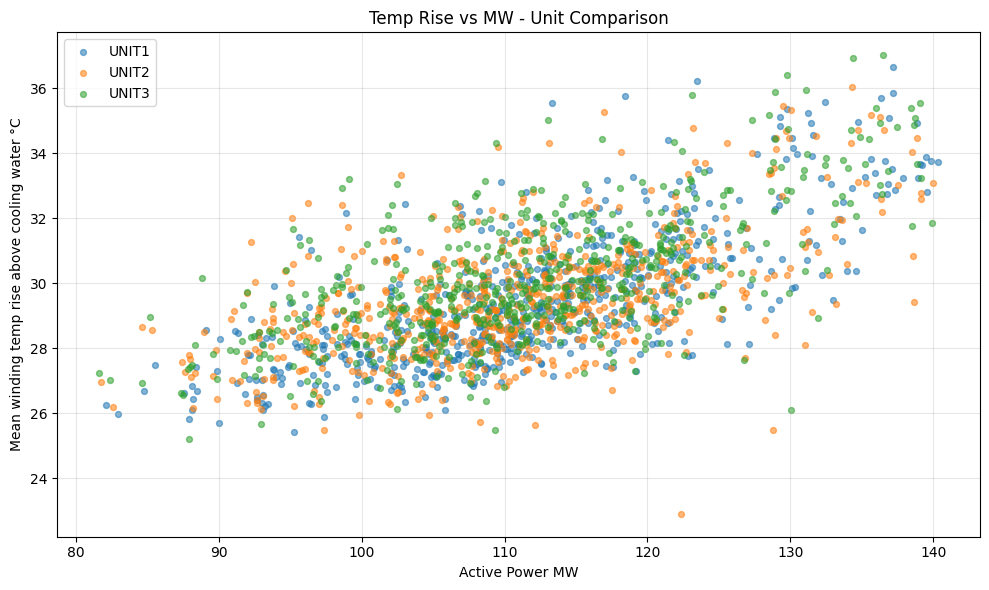

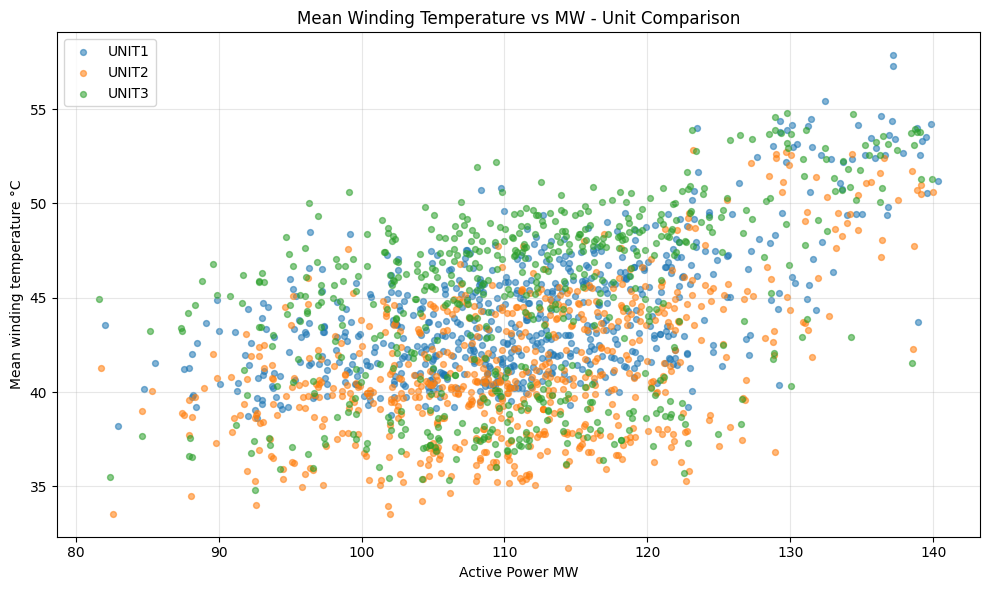

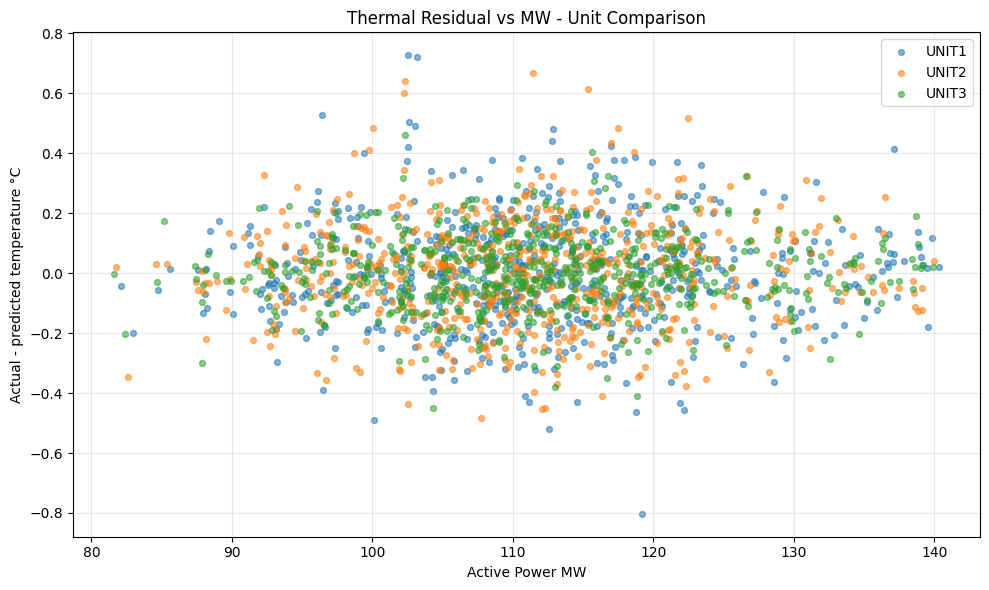

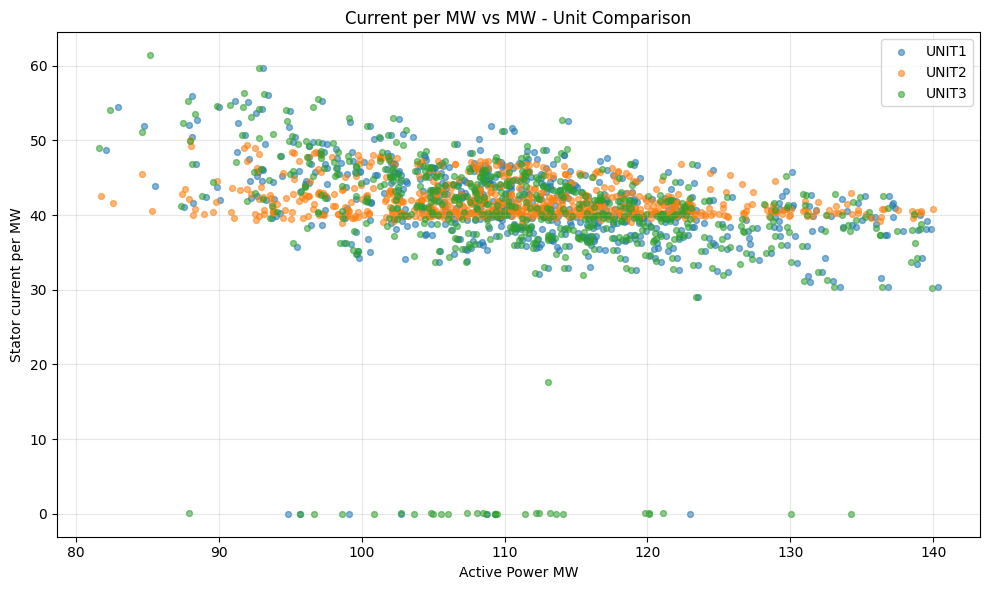

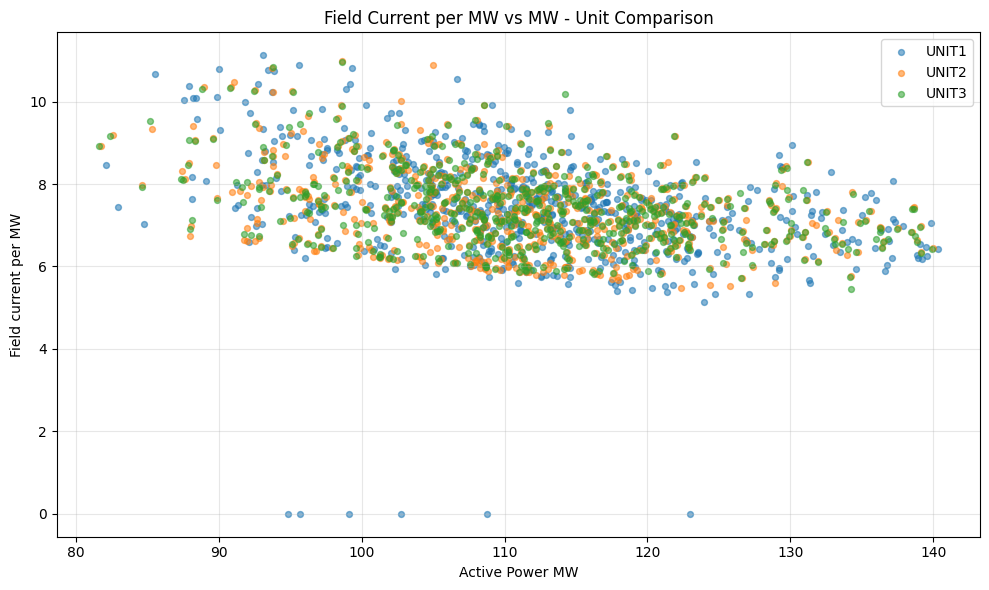

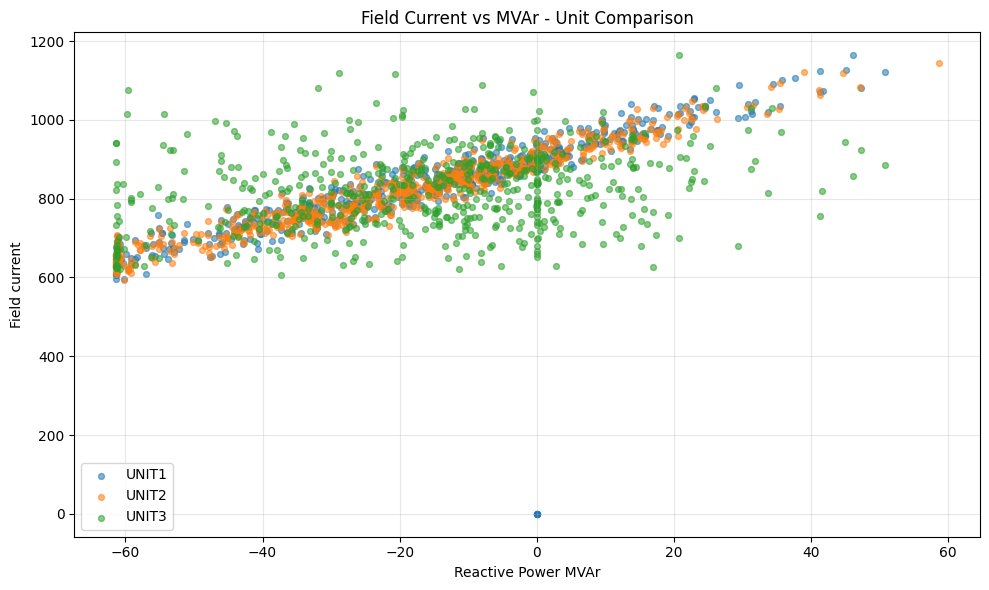

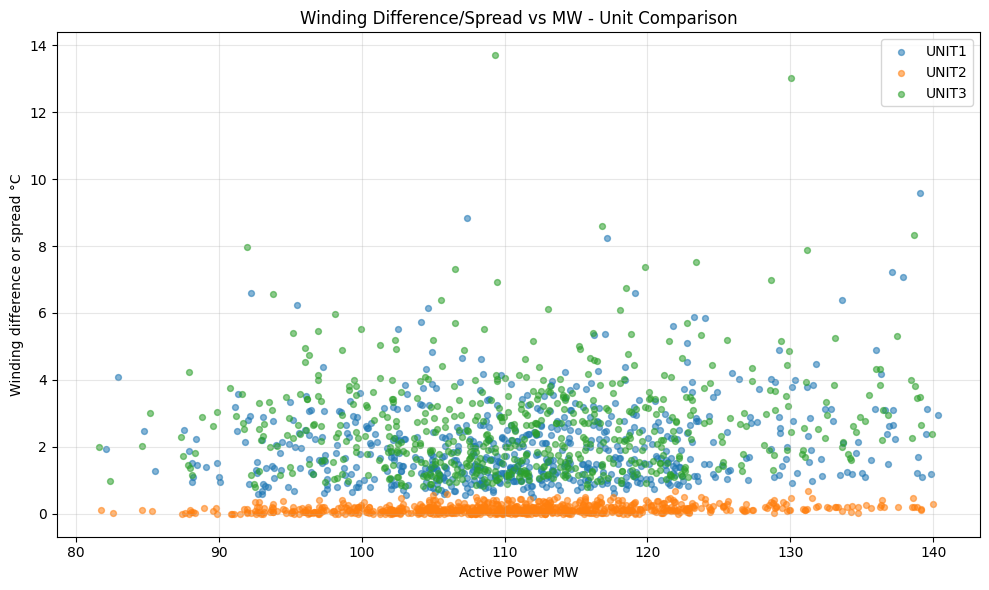

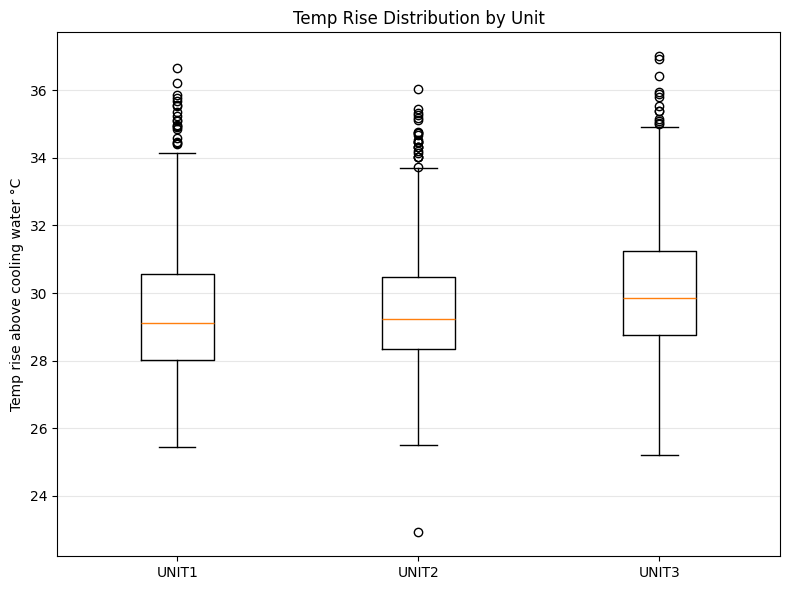

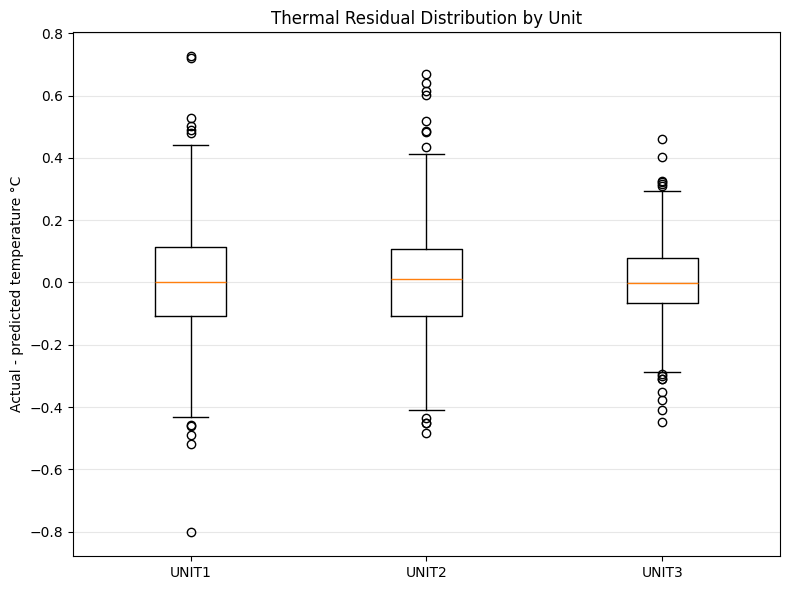

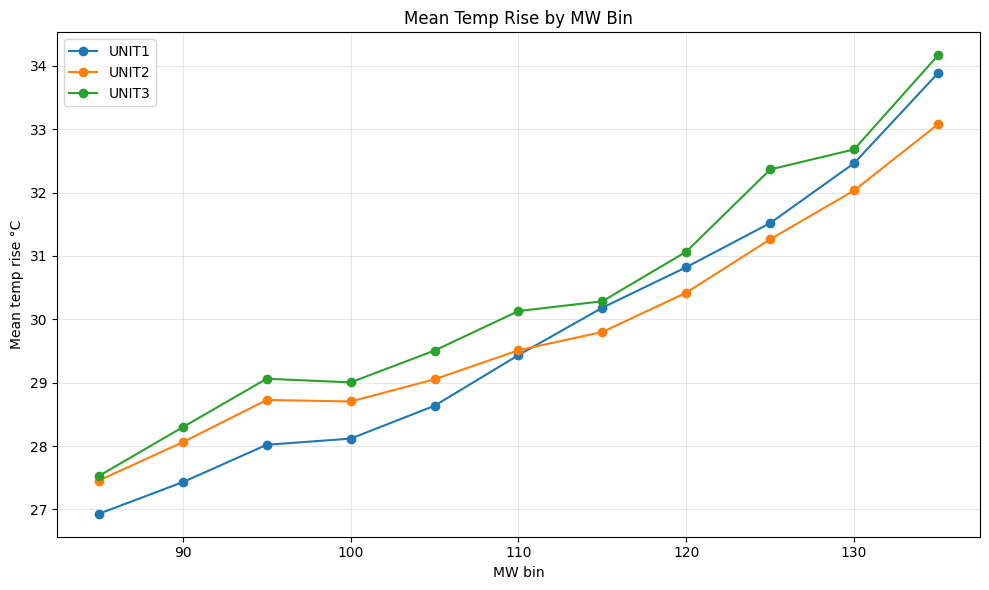

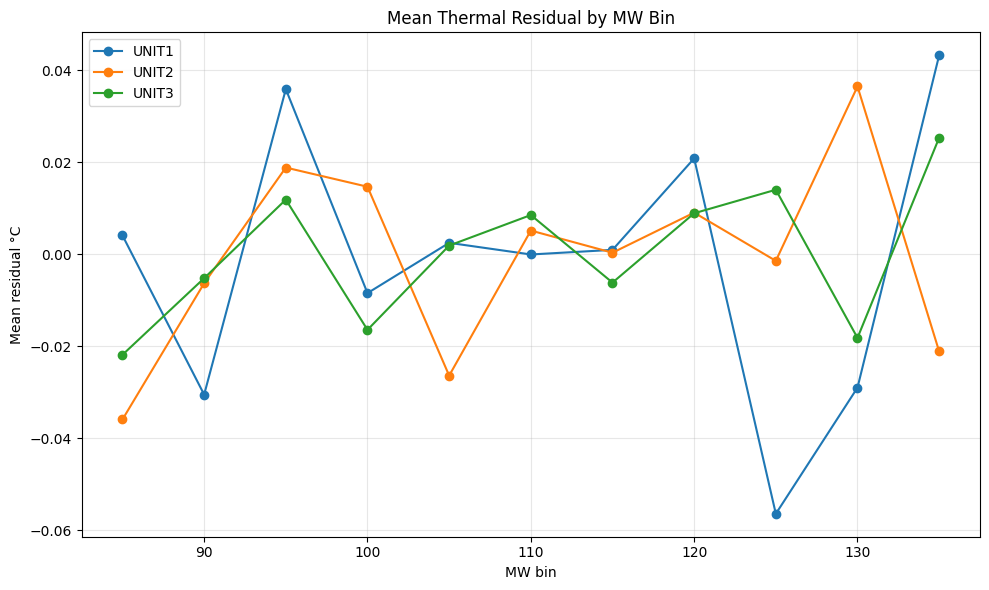

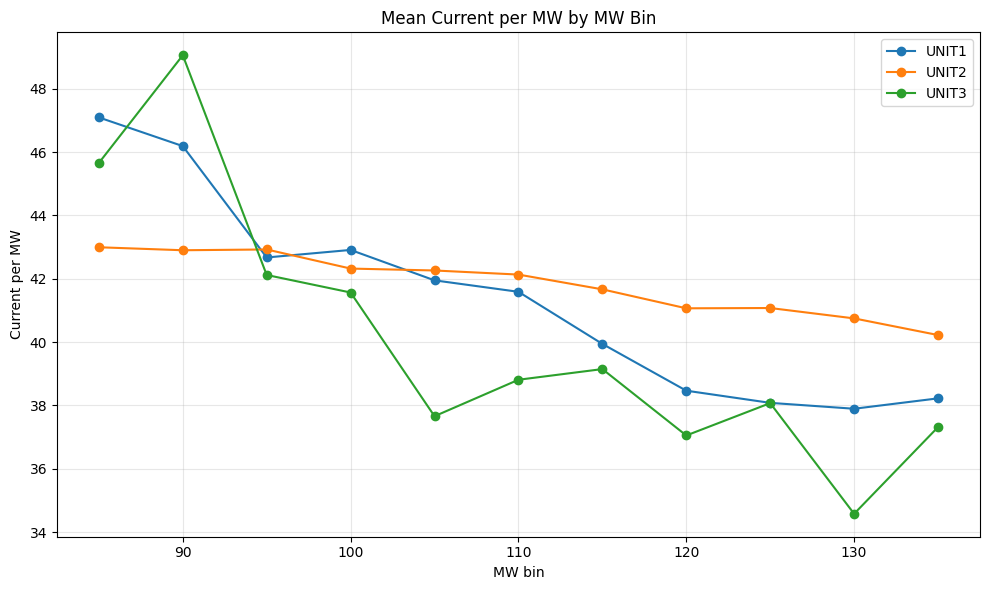

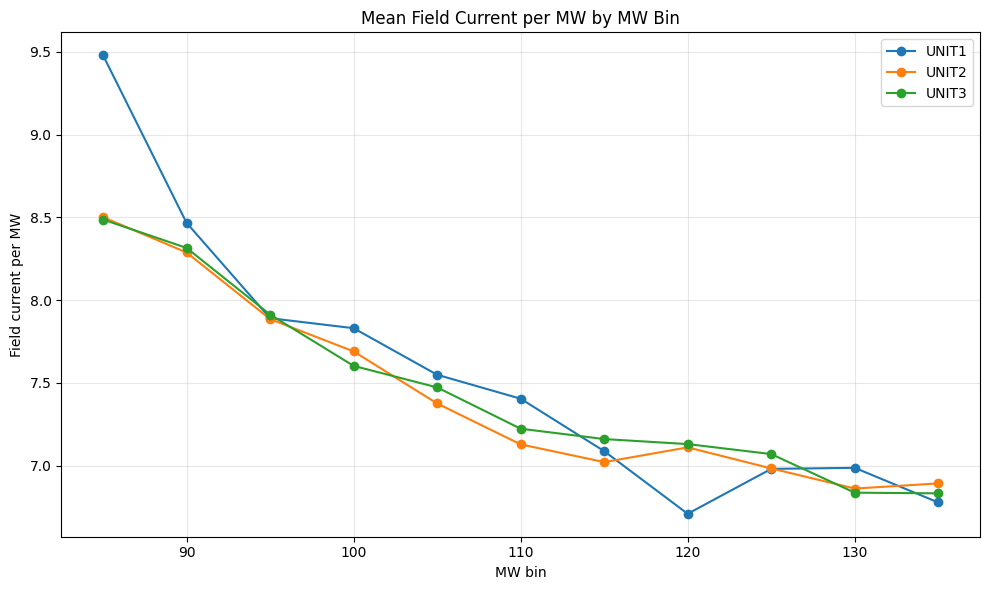

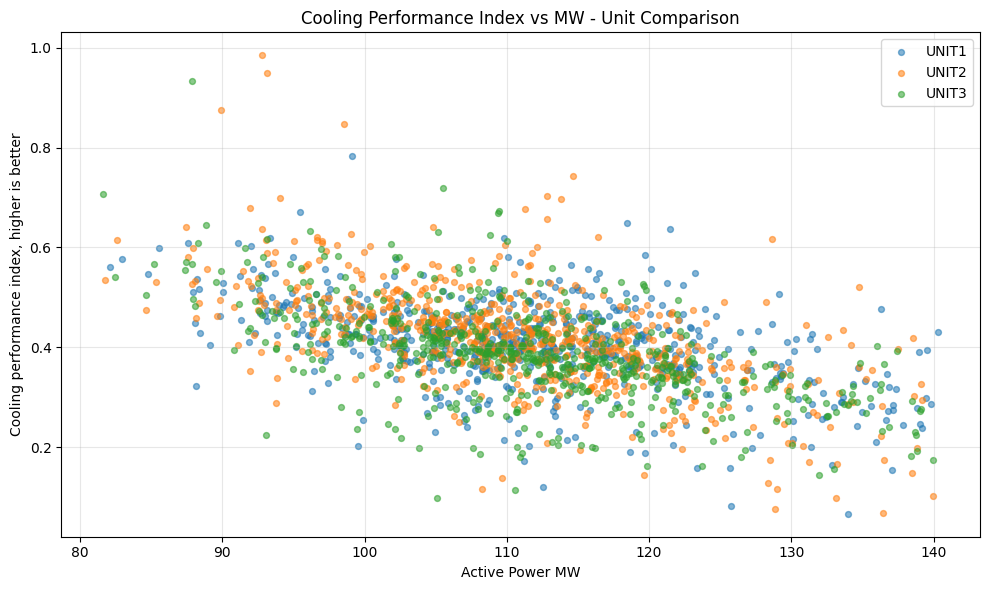

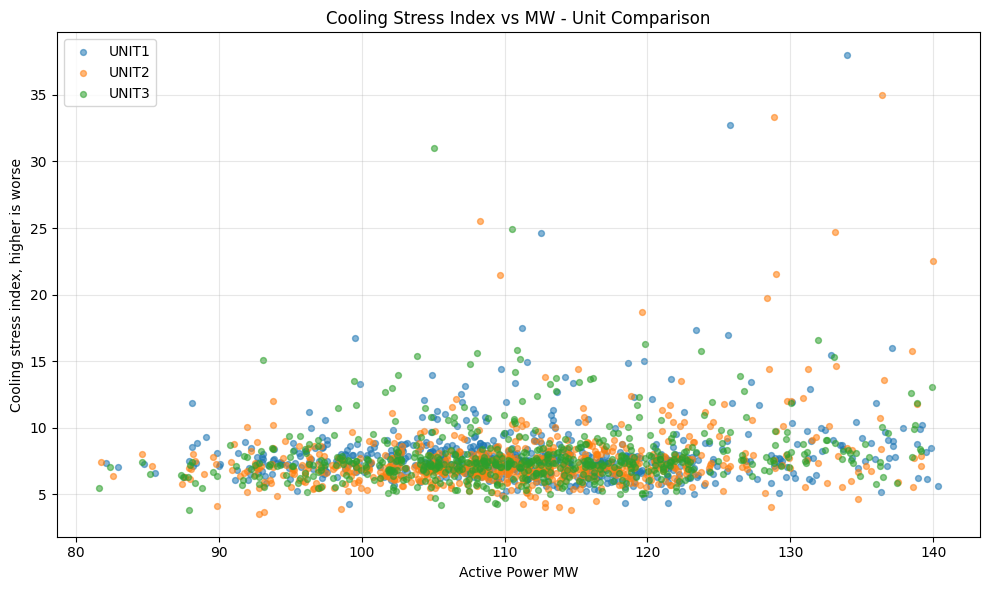

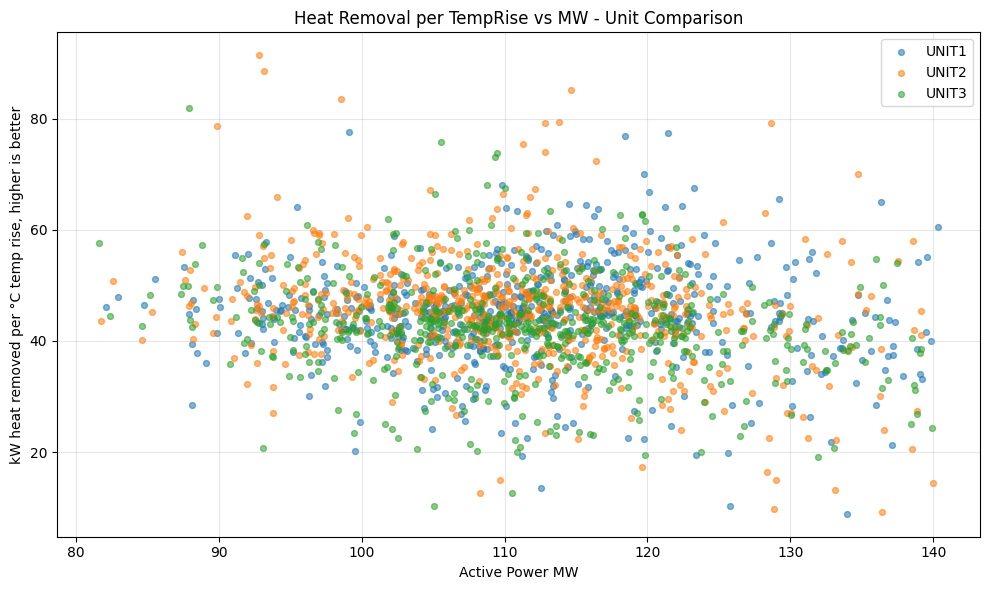

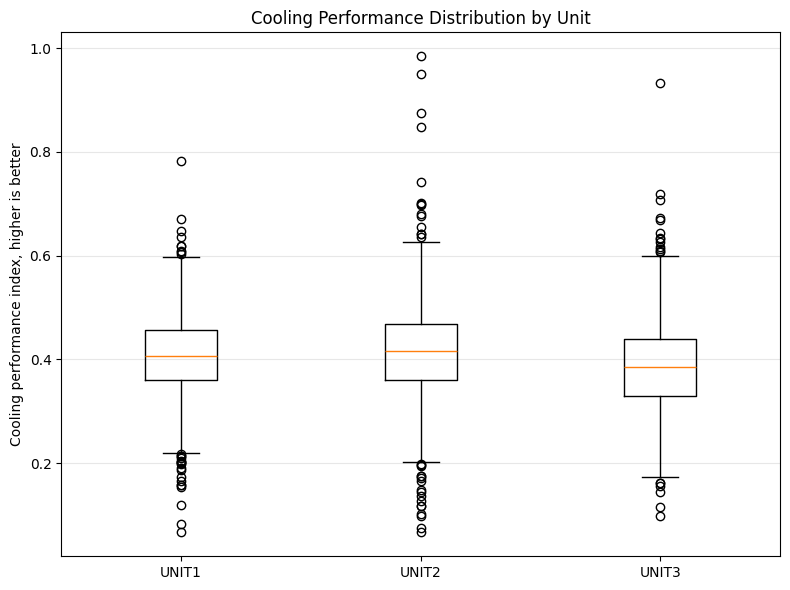

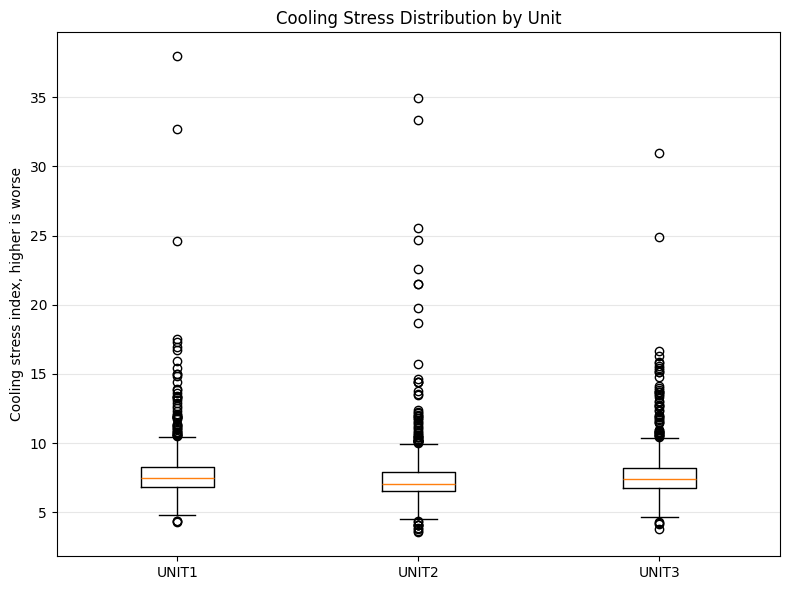

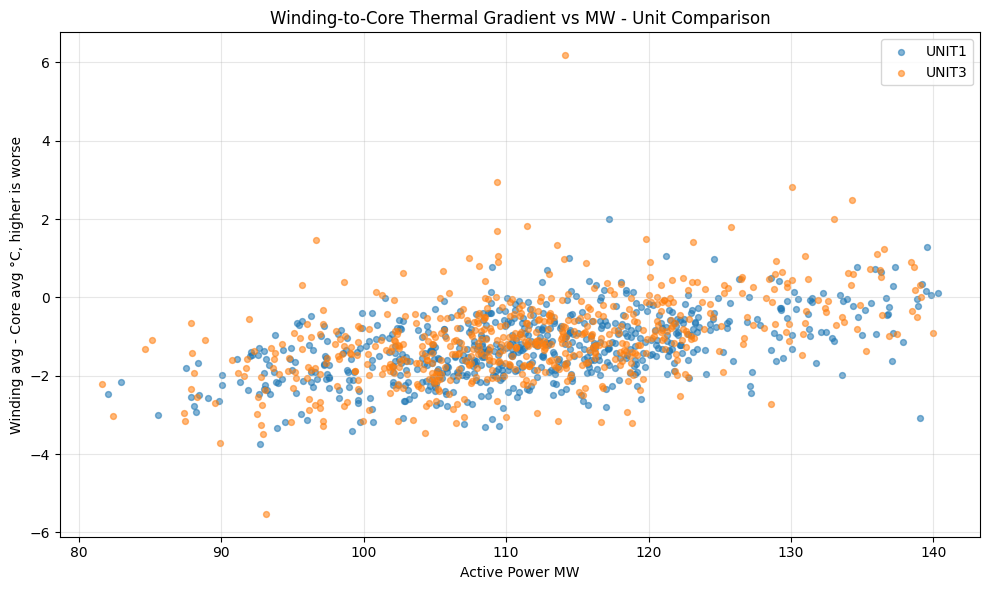

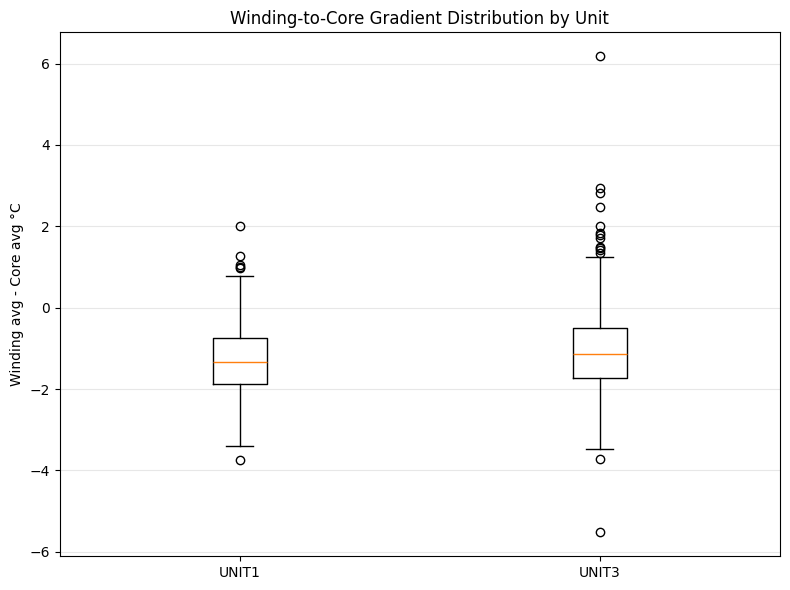

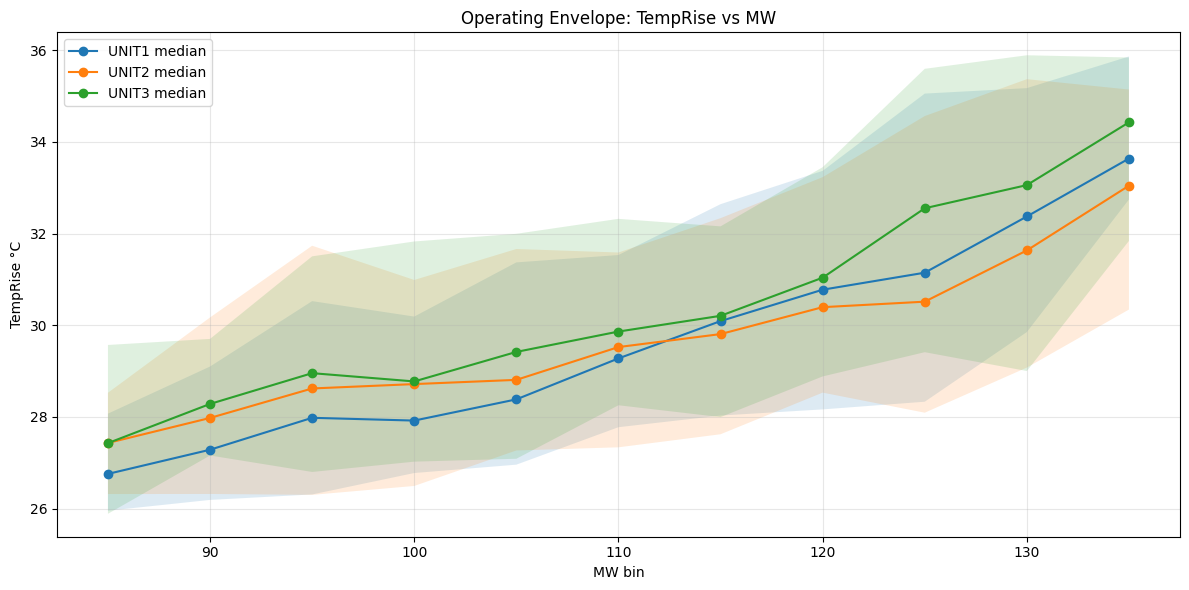

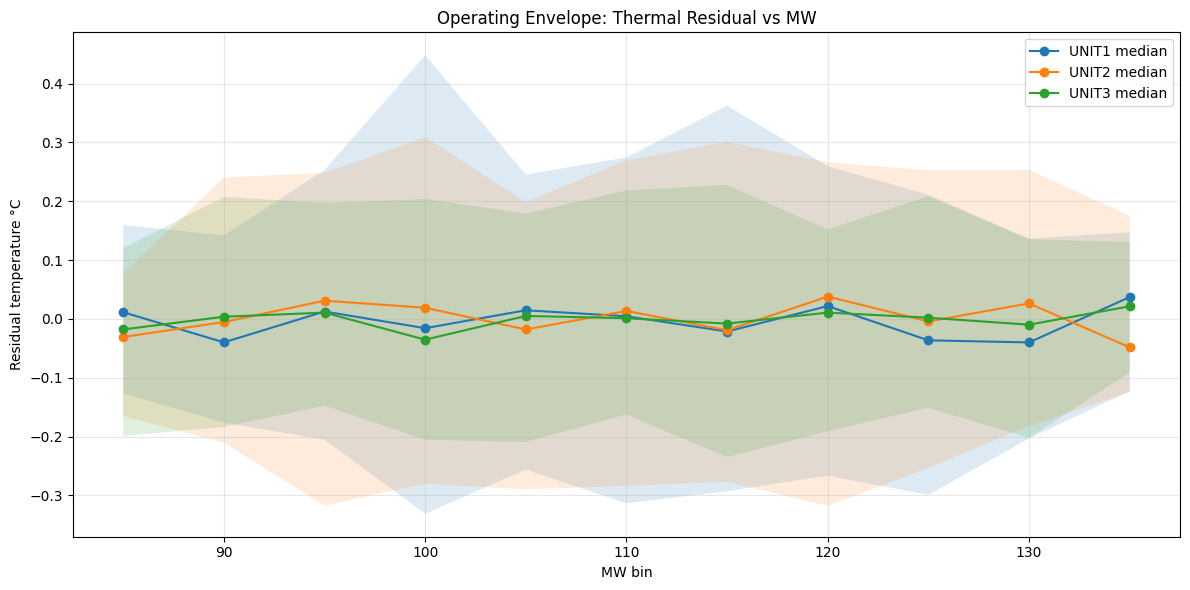

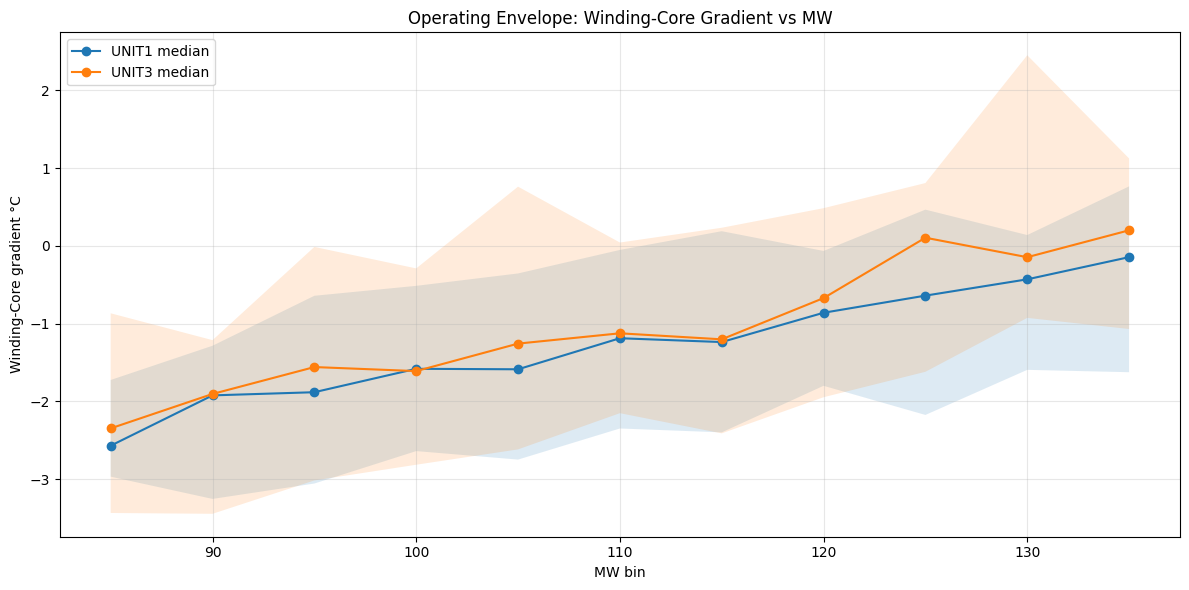

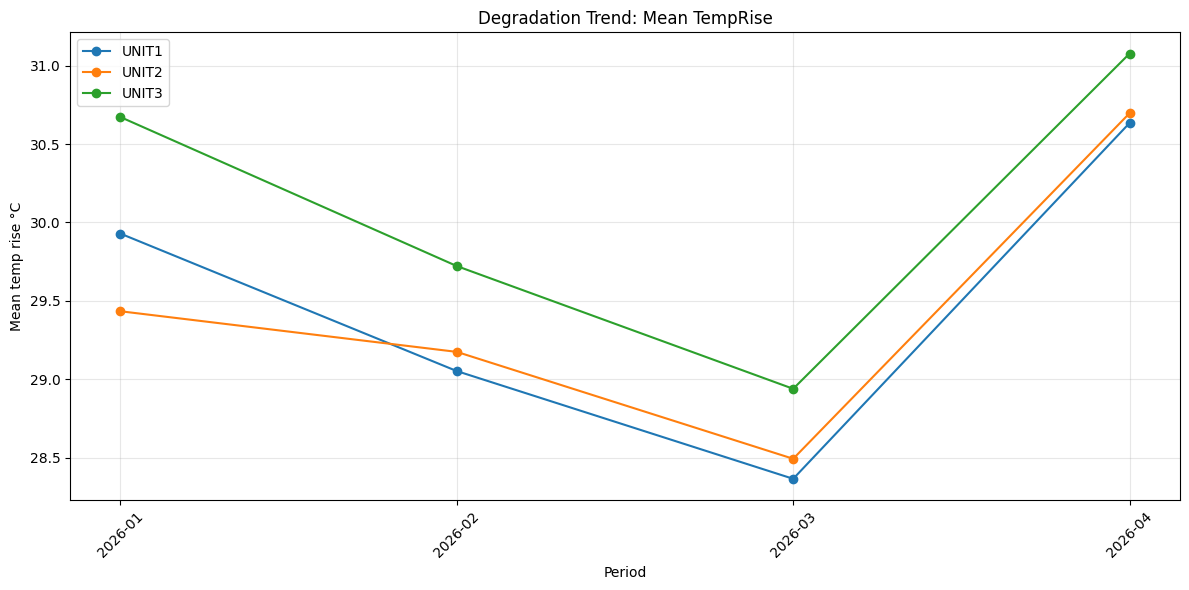

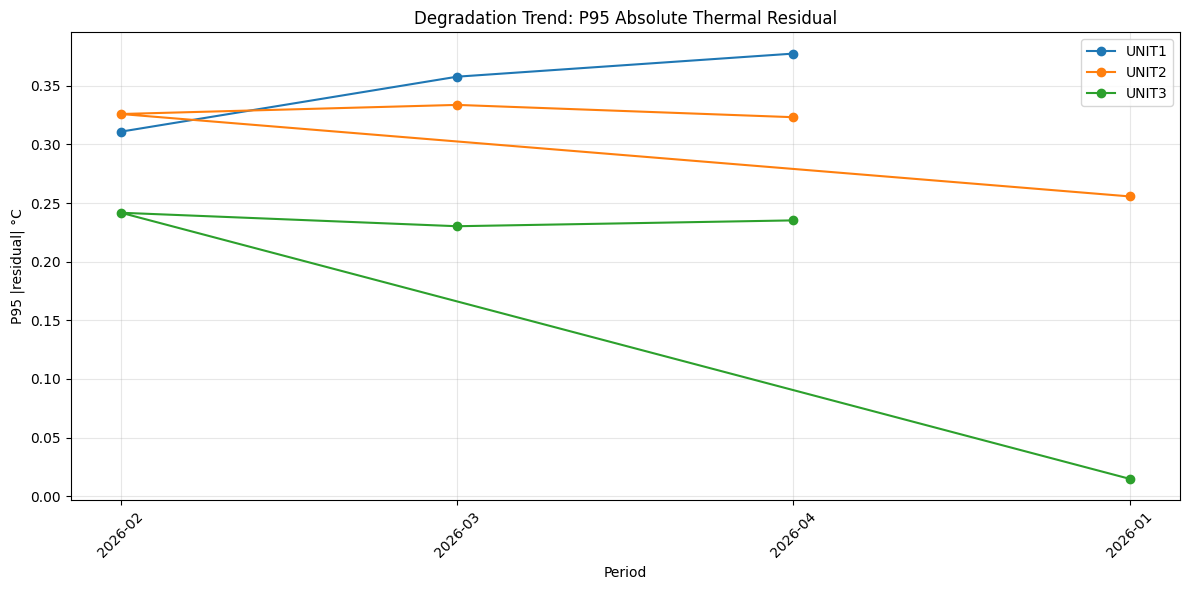

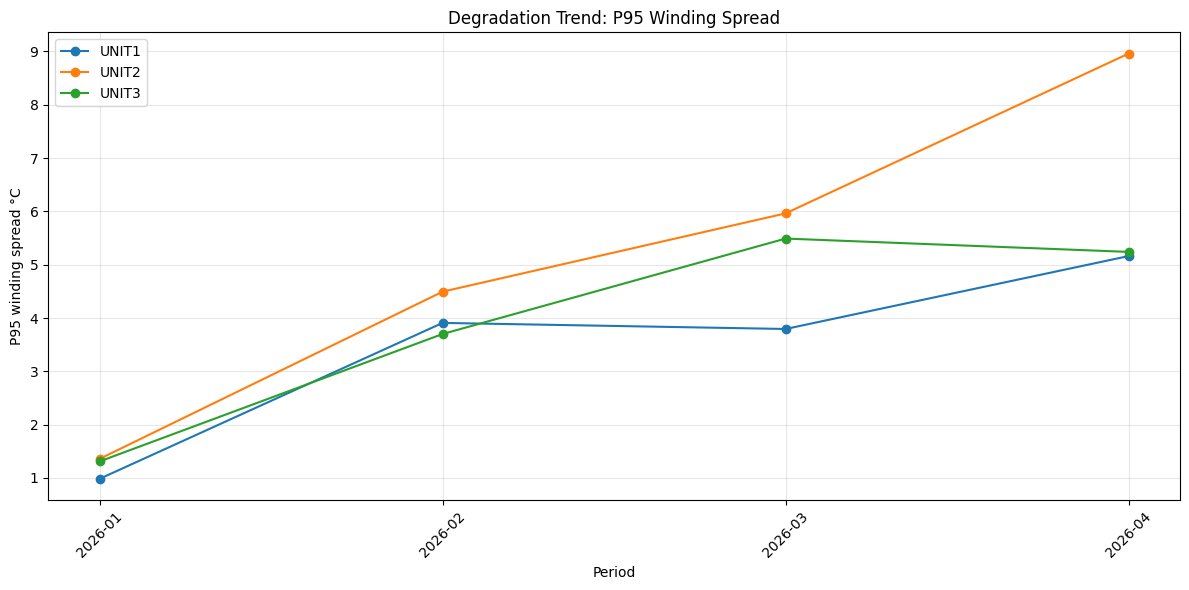

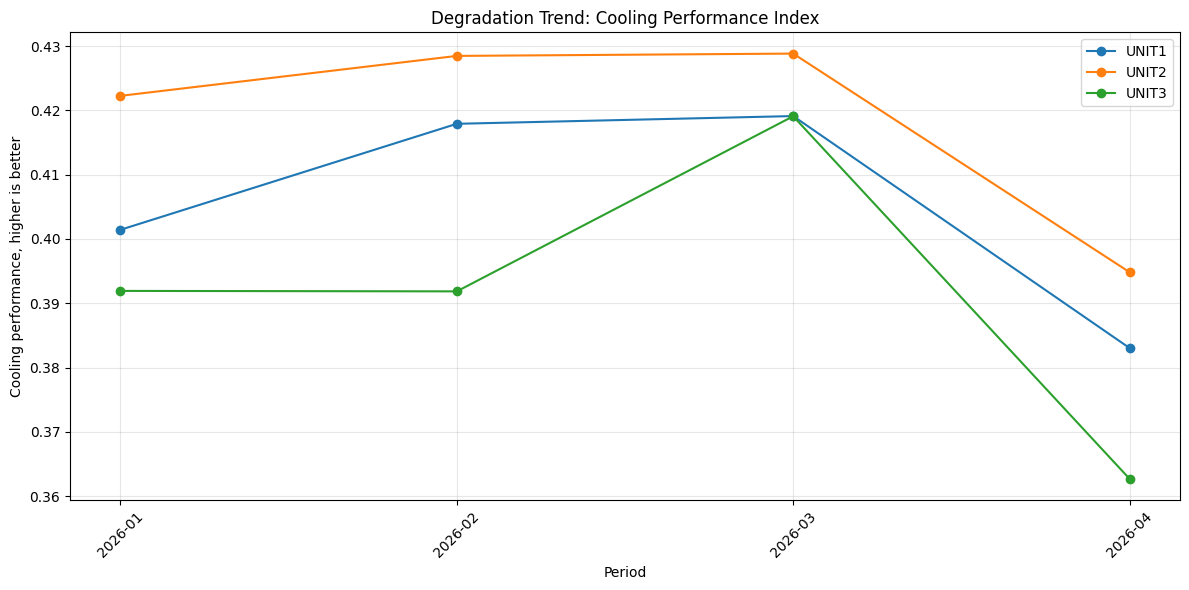

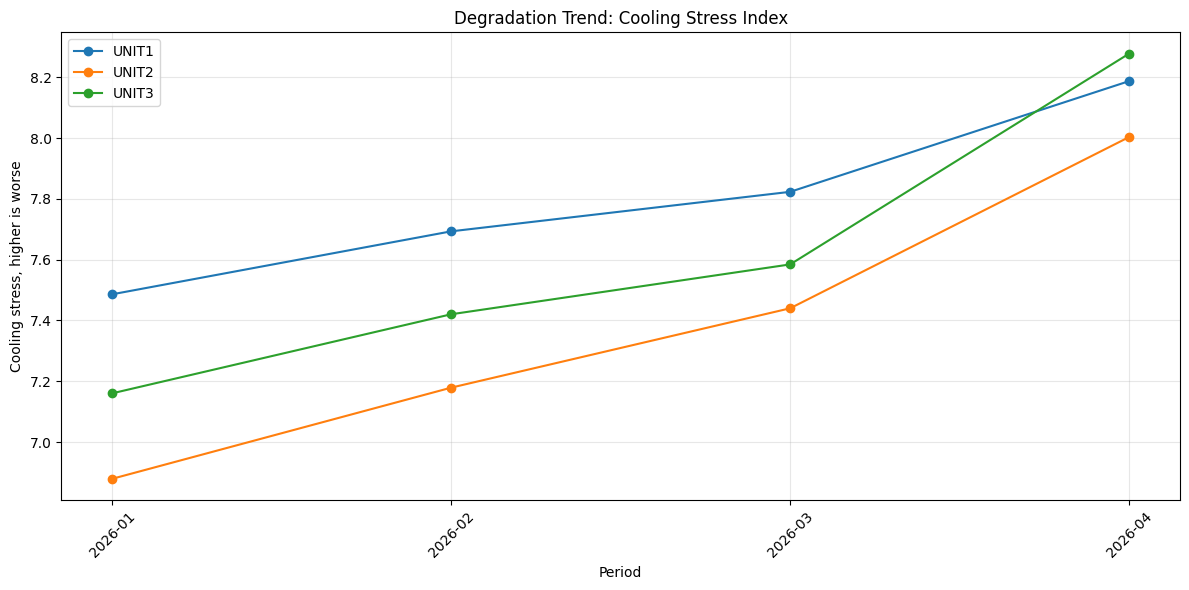

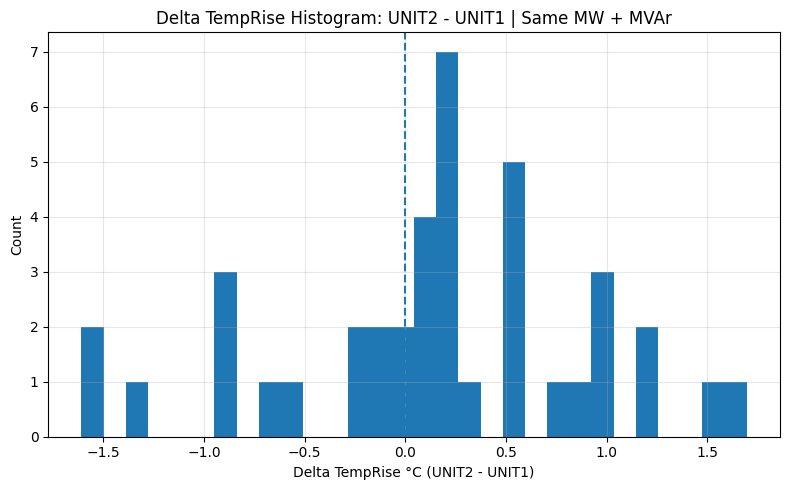

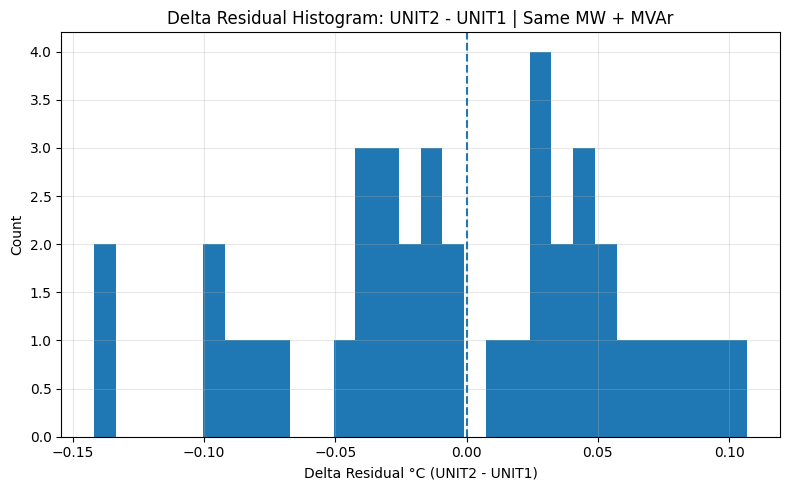

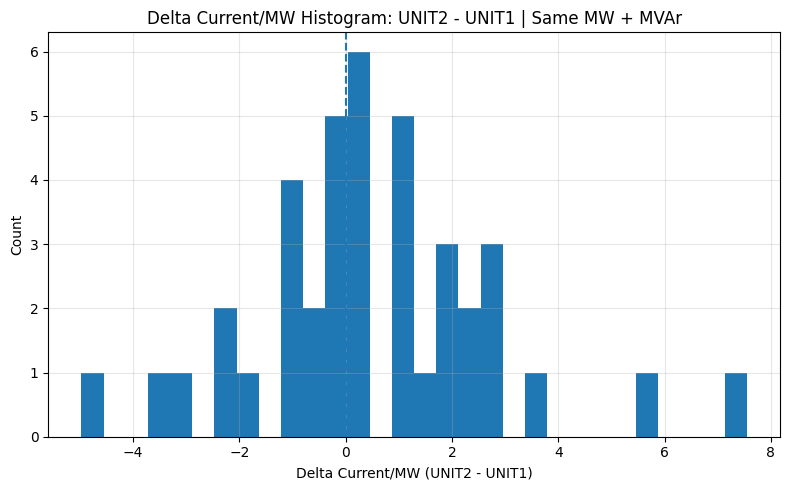

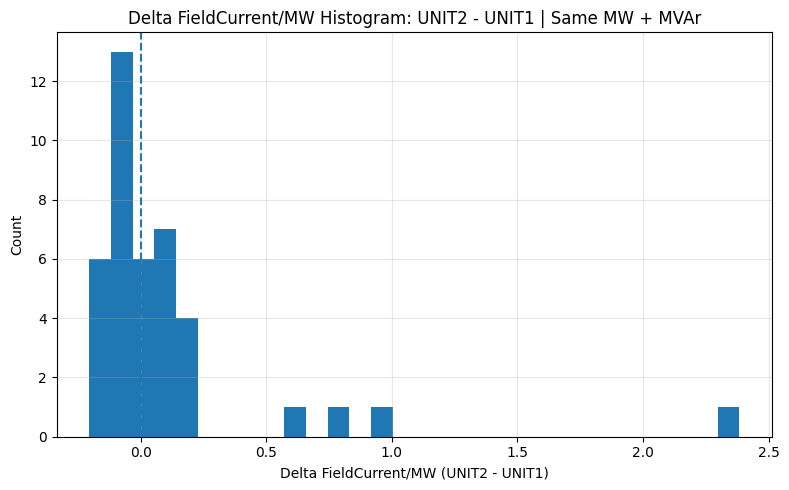

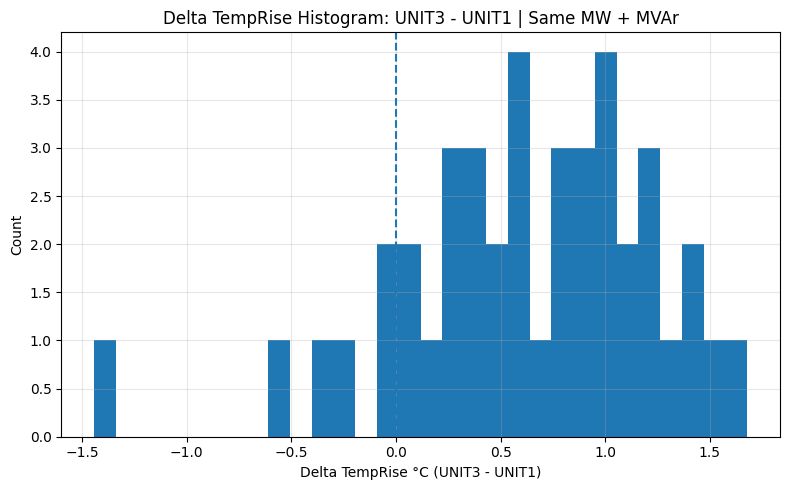

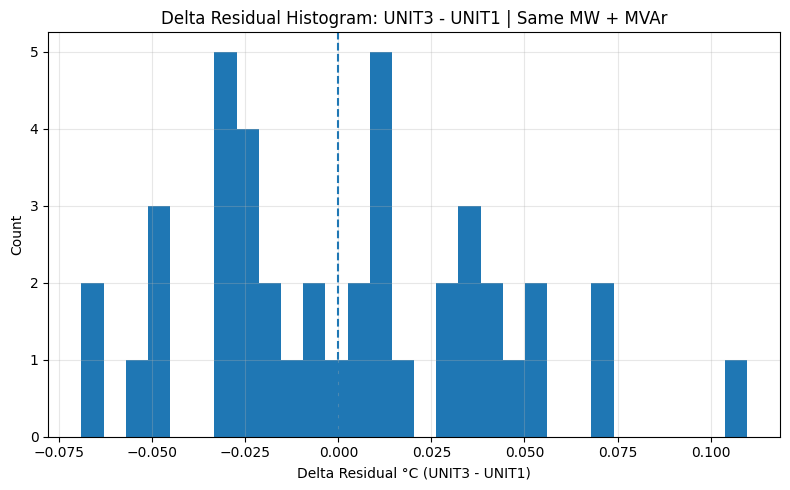

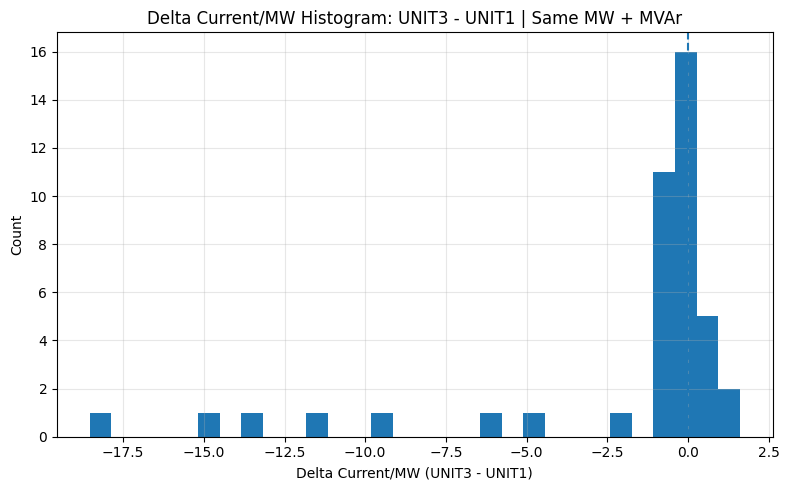

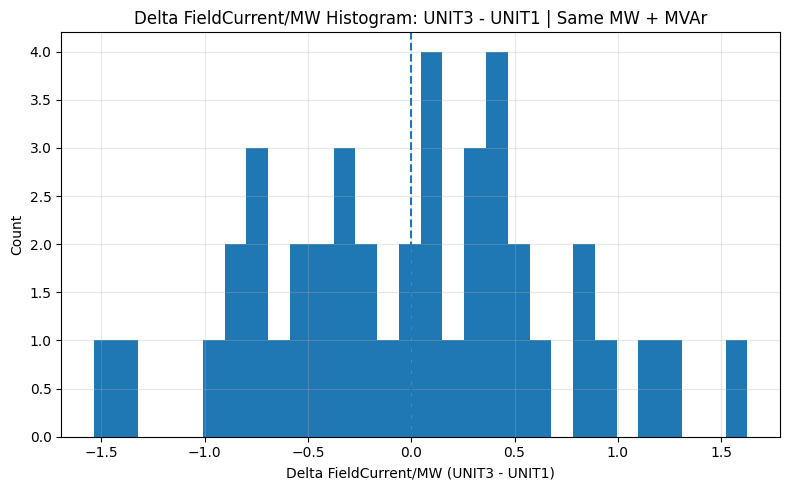

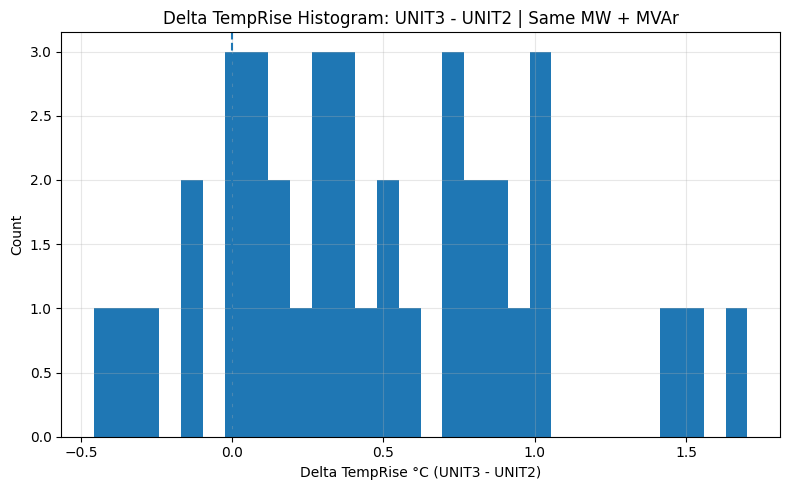

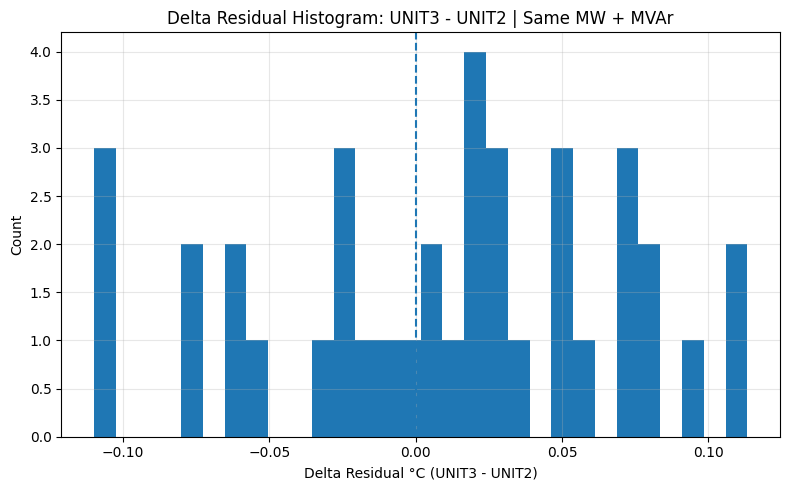

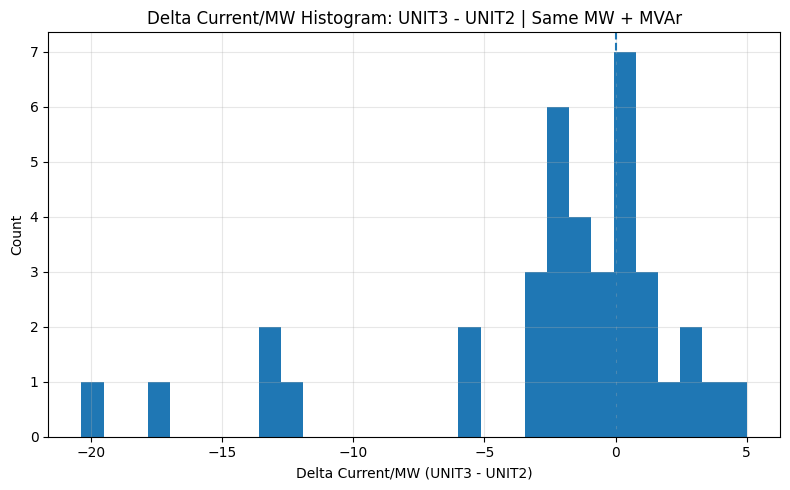

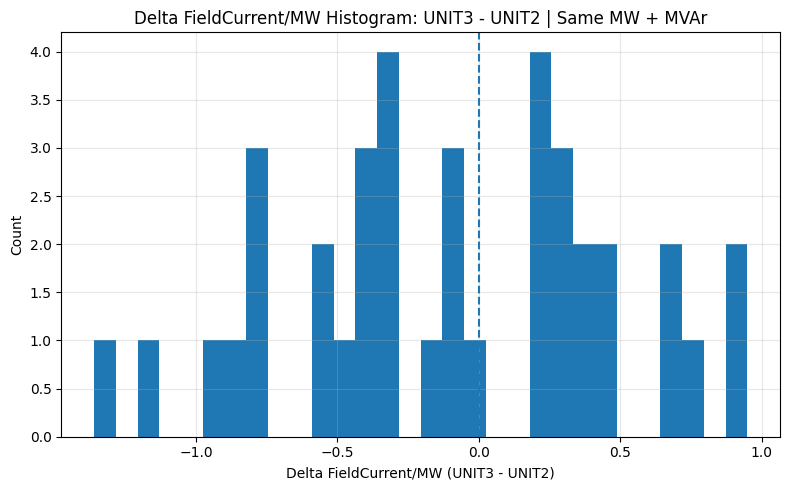


Files saved in: /content/MULTI_UNIT_THERMAL_ELECTRICAL_COMPARISON_OUTPUTS
Excel report: /content/MULTI_UNIT_THERMAL_ELECTRICAL_COMPARISON_OUTPUTS/MULTI_UNIT_Thermal_Electrical_Comparison.xlsx
Done.


In [25]:
import pandas as pd
import numpy as np

# =========================================================
# 11. MAIN
# =========================================================

def main():
    # ---------------- Load and analyze all units ----------------
    raw_units = TWO_FILE_UNITS if USE_TWO_FILE_MODE else UNITS

    analyzed_units = {}
    metrics_by_unit = {}
    summaries = []

    for unit_name, files in raw_units.items():
        try:
            if USE_TWO_FILE_MODE:
                raw_df = load_two_file_unit(unit_name, files)
            else:
                raw_df = load_multi_file_unit(unit_name, files)

            df = preprocess_unit(raw_df, unit_name)
            df, metrics = build_thermal_model(df)
            df, core_metrics = build_core_temperature_model(df)
            metrics.update(core_metrics)

            severity_df = df.apply(classify_row_severity, axis=1)
            df = pd.concat([df, severity_df], axis=1)

            analyzed_units[unit_name] = df
            metrics_by_unit[unit_name] = metrics
            summaries.append(unit_summary(df, metrics, unit_name))

            df.to_csv(output_dir / f"{unit_name}_analysis_dataset.csv", index=False)

        except Exception as e:
            print(f"ERROR for {unit_name}: {e}")

    if len(analyzed_units) < 2:
        raise ValueError("At least two valid units are required for comparison.")

    all_df = pd.concat(analyzed_units.values(), ignore_index=True)
    all_df.to_csv(output_dir / "ALL_UNITS_analysis_dataset.csv", index=False)

    summary_df = pd.DataFrame(summaries)
    summary_df.to_csv(output_dir / "unit_summary.csv", index=False)

    print("\n" + "="*100)
    print("UNIT SUMMARY")
    print("="*100)
    print(summary_df.T)

    # ---------------- Pairwise comparisons ----------------
    units = list(analyzed_units.keys())
    pairwise_outputs = {}
    interpretation_rows = []

    comparison_levels = {
        "Same MW": ["MW_bin"],
        "Same MW + MVAr": ["MW_bin", "MVAr_bin"],
        "Same MW + MVAr + CW": ["MW_bin", "MVAr_bin", "CW_bin"],
    }

    for i in range(len(units)):
        for j in range(i + 1, len(units)):
            u1, u2 = units[i], units[j]
            df1, df2 = analyzed_units[u1], analyzed_units[u2]

            for label, group_cols in comparison_levels.items():
                cmp_df = compare_two_units_by_bins(df1, df2, group_cols, u1, u2)
                key = (u1, u2, label)
                pairwise_outputs[key] = cmp_df

                safe_label = label.replace(" + ", "_").replace(" ", "_")
                if not cmp_df.empty:
                    cmp_df.to_csv(output_dir / f"compare_{u1}_vs_{u2}_{safe_label}.csv", index=False)

                row = summarize_pairwise_delta(cmp_df, u1, u2, label)
                if row is not None:
                    interpretation_rows.append(row)

    interpretation_df = pd.DataFrame(interpretation_rows)
    if not interpretation_df.empty:
        interpretation_df.to_csv(output_dir / "pairwise_interpretation_summary.csv", index=False)
        print("\n" + "="*100)
        print("PAIRWISE INTERPRETATION SUMMARY")
        print("Positive delta means second unit is higher than first unit.")
        print("For temperature, temp rise, residual, current/MW, field-current/MW: positive is usually worse.")
        print("="*100)
        print(interpretation_df.round(4))

    # ---------------- 3-unit same-condition ranking ----------------
    if len(units) >= 3:
        group_cols = ["MW_bin", "MVAr_bin", "CW_bin"]
        same_all = grouped_stats(all_df, ["Unit"] + group_cols, min_count=MIN_BIN_COUNT)

        common_bin_counts = same_all.groupby(group_cols, observed=True)["Unit"].nunique().reset_index(name="UnitCount")
        common_bins = common_bin_counts[common_bin_counts["UnitCount"] == len(units)][group_cols]
        same_all_common = same_all.merge(common_bins, on=group_cols, how="inner")

        same_all_common["Rank_TempRise_Worst1"] = same_all_common.groupby(group_cols, observed=True)["TempRise_mean"].rank(ascending=False, method="dense")
        same_all_common["Rank_Residual_Worst1"] = same_all_common.groupby(group_cols, observed=True)["Residual_mean"].rank(ascending=False, method="dense")
        same_all_common["Rank_CurrentPerMW_Worst1"] = same_all_common.groupby(group_cols, observed=True)["Current_per_MW_mean"].rank(ascending=False, method="dense")
        same_all_common["Rank_FieldCurrentPerMW_Worst1"] = same_all_common.groupby(group_cols, observed=True)["FieldCurrent_per_MW_mean"].rank(ascending=False, method="dense")

        rank_summary = same_all_common.groupby("Unit").agg(
            Common_Bin_Count=("TempRise_mean", "count"),
            Avg_Rank_TempRise_Worst1=("Rank_TempRise_Worst1", "mean"),
            Avg_Rank_Residual_Worst1=("Rank_Residual_Worst1", "mean"),
            Avg_Rank_CurrentPerMW_Worst1=("Rank_CurrentPerMW_Worst1", "mean"),
            Avg_Rank_FieldCurrentPerMW_Worst1=("Rank_FieldCurrentPerMW_Worst1", "mean"),
            Worst_TempRise_Bin_Count=("Rank_TempRise_Worst1", lambda s: (s == 1).sum()),
            Worst_Residual_Bin_Count=("Rank_Residual_Worst1", lambda s: (s == 1).sum()),
            Worst_CurrentPerMW_Bin_Count=("Rank_CurrentPerMW_Worst1", lambda s: (s == 1).sum()),
            Worst_FieldCurrentPerMW_Bin_Count=("Rank_FieldCurrentPerMW_Worst1", lambda s: (s == 1).sum()),
        ).reset_index()

        same_all_common.to_csv(output_dir / "three_unit_common_same_condition_bins.csv", index=False)
        rank_summary.to_csv(output_dir / "three_unit_rank_summary.csv", index=False)

        print("\n" + "="*100)
        print("3-UNIT SAME-CONDITION RANK SUMMARY")
        print("Rank 1 = worst/highest for that KPI inside same MW + MVAr + CW bin.")
        print("="*100)
        print(rank_summary.round(3))
    else:
        same_all_common = pd.DataFrame()
        rank_summary = pd.DataFrame()

    # ---------------- Useful comparison plots ----------------
    save_scatter_units(
        all_df, "MW", "TempRise",
        "Temp Rise vs MW - Unit Comparison",
        "Active Power MW", "Mean winding temp rise above cooling water °C",
        "01_temprise_vs_MW_units.png"
    )

    save_scatter_units(
        all_df, "MW", "MeanWindingTemp",
        "Mean Winding Temperature vs MW - Unit Comparison",
        "Active Power MW", "Mean winding temperature °C",
        "02_winding_temp_vs_MW_units.png"
    )

    save_scatter_units(
        all_df, "MW", "ResidualTemp",
        "Thermal Residual vs MW - Unit Comparison",
        "Active Power MW", "Actual - predicted temperature °C",
        "03_residual_vs_MW_units.png"
    )

    save_scatter_units(
        all_df, "MW", "Current_per_MW",
        "Current per MW vs MW - Unit Comparison",
        "Active Power MW", "Stator current per MW",
        "04_current_per_MW_units.png"
    )

    save_scatter_units(
        all_df, "MW", "FieldCurrent_per_MW",
        "Field Current per MW vs MW - Unit Comparison",
        "Active Power MW", "Field current per MW",
        "05_field_current_per_MW_units.png"
    )

    save_scatter_units(
        all_df, "MVAr", "FieldCurrent",
        "Field Current vs MVAr - Unit Comparison",
        "Reactive Power MVAr", "Field current",
        "06_field_current_vs_MVAr_units.png"
    )

    save_scatter_units(
        all_df, "MW", "WindingDiff",
        "Winding Difference/Spread vs MW - Unit Comparison",
        "Active Power MW", "Winding difference or spread °C",
        "07_winding_diff_vs_MW_units.png"
    )

    save_boxplot_units(
        all_df, "TempRise",
        "Temp Rise Distribution by Unit",
        "Temp rise above cooling water °C",
        "08_boxplot_temprise_by_unit.png"
    )

    save_boxplot_units(
        all_df, "ResidualTemp",
        "Thermal Residual Distribution by Unit",
        "Actual - predicted temperature °C",
        "09_boxplot_residual_by_unit.png"
    )

    # Mean by MW bin line plots
    mw_line = all_df.groupby(["Unit", "MW_bin"], observed=True).agg(
        Count=("TempRise", "count"),
        TempRise_mean=("TempRise", "mean"),
        Residual_mean=("ResidualTemp", "mean"),
        Current_per_MW_mean=("Current_per_MW", "mean"),
        FieldCurrent_per_MW_mean=("FieldCurrent_per_MW", "mean"),
        WindingDiff_mean=("WindingDiff", "mean"),
    ).reset_index()
    mw_line = mw_line[mw_line["Count"] >= MIN_BIN_COUNT]

    save_line_by_unit(
        mw_line, "MW_bin", "TempRise_mean",
        "Mean Temp Rise by MW Bin",
        "MW bin", "Mean temp rise °C",
        "10_line_temprise_by_MW_bin.png"
    )

    save_line_by_unit(
        mw_line, "MW_bin", "Residual_mean",
        "Mean Thermal Residual by MW Bin",
        "MW bin", "Mean residual °C",
        "11_line_residual_by_MW_bin.png"
    )

    save_line_by_unit(
        mw_line, "MW_bin", "Current_per_MW_mean",
        "Mean Current per MW by MW Bin",
        "MW bin", "Current per MW",
        "12_line_current_per_MW_by_MW_bin.png"
    )

    save_line_by_unit(
        mw_line, "MW_bin", "FieldCurrent_per_MW_mean",
        "Mean Field Current per MW by MW Bin",
        "MW bin", "Field current per MW",
        "13_line_field_current_per_MW_by_MW_bin.png"
    )

    # ---------------- Cooling efficiency plots ----------------
    save_scatter_units(
        all_df, "MW", "CoolingPerformanceIndex",
        "Cooling Performance Index vs MW - Unit Comparison",
        "Active Power MW", "Cooling performance index, higher is better",
        "18_cooling_performance_vs_MW_units.png"
    )

    save_scatter_units(
        all_df, "MW", "CoolingStressIndex",
        "Cooling Stress Index vs MW - Unit Comparison",
        "Active Power MW", "Cooling stress index, higher is worse",
        "19_cooling_stress_vs_MW_units.png"
    )

    save_scatter_units(
        all_df, "MW", "HeatRemoval_per_TempRise",
        "Heat Removal per TempRise vs MW - Unit Comparison",
        "Active Power MW", "kW heat removed per °C temp rise, higher is better",
        "20_heat_removal_per_temprise_vs_MW_units.png"
    )

    save_boxplot_units(
        all_df, "CoolingPerformanceIndex",
        "Cooling Performance Distribution by Unit",
        "Cooling performance index, higher is better",
        "21_boxplot_cooling_performance_by_unit.png"
    )

    save_boxplot_units(
        all_df, "CoolingStressIndex",
        "Cooling Stress Distribution by Unit",
        "Cooling stress index, higher is worse",
        "22_boxplot_cooling_stress_by_unit.png"
    )

    save_scatter_units(
        all_df, "MW", "WindingCoreGradient",
        "Winding-to-Core Thermal Gradient vs MW - Unit Comparison",
        "Active Power MW", "Winding avg - Core avg °C, higher is worse",
        "28_winding_core_gradient_vs_MW_units.png"
    )

    save_boxplot_units(
        all_df, "WindingCoreGradient",
        "Winding-to-Core Gradient Distribution by Unit",
        "Winding avg - Core avg °C",
        "29_boxplot_winding_core_gradient_by_unit.png"
    )

    # Operating envelopes: median with 5%-95% band
    env_temprise = save_operating_envelope_plot(
        all_df, "TempRise",
        "Operating Envelope: TempRise vs MW",
        "TempRise °C",
        "30_envelope_temprise_vs_MW.png"
    )
    env_residual = save_operating_envelope_plot(
        all_df, "ResidualTemp",
        "Operating Envelope: Thermal Residual vs MW",
        "Residual temperature °C",
        "31_envelope_residual_vs_MW.png"
    )
    env_gradient = save_operating_envelope_plot(
        all_df, "WindingCoreGradient",
        "Operating Envelope: Winding-Core Gradient vs MW",
        "Winding-Core gradient °C",
        "32_envelope_winding_core_gradient_vs_MW.png"
    )

    # ---------------- Degradation trend ----------------
    # Use monthly trend by default. Change freq='D' or 'W' if your file is short period only.
    trend_summary = build_degradation_trend(all_df, freq="M")
    trend_slopes = add_trend_slopes(
        trend_summary,
        y_cols=[
            "TempRise_mean", "TempRise_p95", "WindingSpread_mean", "WindingSpread_p95",
            "Residual_mean", "Residual_p95_abs", "Current_per_MW_mean",
            "FieldCurrent_per_MW_mean", "TempRise_per_MW_mean", "TempRise_per_I2_mean",
            "CoolingPerformance_mean", "CoolingStress_mean", "HeatRemoval_per_TempRise_mean",

        ]
    )

    trend_summary.to_csv(output_dir / "degradation_trend_summary.csv", index=False)
    trend_slopes.to_csv(output_dir / "degradation_trend_slopes.csv", index=False)

    save_trend_plot(
        trend_summary, "TempRise_mean",
        "Degradation Trend: Mean TempRise",
        "Mean temp rise °C",
        "23_trend_temprise_mean.png"
    )

    save_trend_plot(
        trend_summary, "Residual_p95_abs",
        "Degradation Trend: P95 Absolute Thermal Residual",
        "P95 |residual| °C",
        "24_trend_residual_p95_abs.png"
    )

    save_trend_plot(
        trend_summary, "WindingSpread_p95",
        "Degradation Trend: P95 Winding Spread",
        "P95 winding spread °C",
        "25_trend_winding_spread_p95.png"
    )

    save_trend_plot(
        trend_summary, "CoolingPerformance_mean",
        "Degradation Trend: Cooling Performance Index",
        "Cooling performance, higher is better",
        "26_trend_cooling_performance.png"
    )

    save_trend_plot(
        trend_summary, "CoolingStress_mean",
        "Degradation Trend: Cooling Stress Index",
        "Cooling stress, higher is worse",
        "27_trend_cooling_stress.png"
    )

    # Pairwise delta plots mainly for Same MW + MVAr comparison
    for (u1, u2, label), cmp_df in pairwise_outputs.items():
        if label != "Same MW + MVAr" or cmp_df.empty:
            continue

        delta_temp = f"Delta_TempRise_mean_{u2}_minus_{u1}"
        delta_res = f"Delta_Residual_mean_{u2}_minus_{u1}"
        delta_cur = f"Delta_Current_per_MW_mean_{u2}_minus_{u1}"
        delta_fcur = f"Delta_FieldCurrent_per_MW_mean_{u2}_minus_{u1}"

        save_delta_hist(
            cmp_df, delta_temp,
            f"Delta TempRise Histogram: {u2} - {u1} | Same MW + MVAr",
            f"Delta TempRise °C ({u2} - {u1})",
            f"14_hist_delta_temprise_{u2}_minus_{u1}.png"
        )
        save_delta_hist(
            cmp_df, delta_res,
            f"Delta Residual Histogram: {u2} - {u1} | Same MW + MVAr",
            f"Delta Residual °C ({u2} - {u1})",
            f"15_hist_delta_residual_{u2}_minus_{u1}.png"
        )
        save_delta_hist(
            cmp_df, delta_cur,
            f"Delta Current/MW Histogram: {u2} - {u1} | Same MW + MVAr",
            f"Delta Current/MW ({u2} - {u1})",
            f"16_hist_delta_current_per_MW_{u2}_minus_{u1}.png"
        )
        save_delta_hist(
            cmp_df, delta_fcur,
            f"Delta FieldCurrent/MW Histogram: {u2} - {u1} | Same MW + MVAr",
            f"Delta FieldCurrent/MW ({u2} - {u1})",
            f"17_hist_delta_field_current_per_MW_{u2}_minus_{u1}.png"
        )

    # ---------------- Excel output ----------------
    excel_path = output_dir / "MULTI_UNIT_Thermal_Electrical_Comparison.xlsx"
    with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
        summary_df.to_excel(writer, sheet_name="Unit_Summary", index=False)
        all_df.to_excel(writer, sheet_name="All_Data", index=False)
        if not interpretation_df.empty:
            interpretation_df.to_excel(writer, sheet_name="Pairwise_Summary", index=False)
        if not rank_summary.empty:
            rank_summary.to_excel(writer, sheet_name="3Unit_Rank", index=False)
            same_all_common.to_excel(writer, sheet_name="3Unit_Common_Bins", index=False)
        if 'trend_summary' in locals() and not trend_summary.empty:
            trend_summary.to_excel(writer, sheet_name="Degradation_Trend", index=False)
        if 'trend_slopes' in locals() and not trend_slopes.empty:
            trend_slopes.to_excel(writer, sheet_name="Trend_Slopes", index=False)
        if 'env_temprise' in locals() and not env_temprise.empty:
            env_temprise.to_excel(writer, sheet_name="Envelope_TempRise", index=False)
        if 'env_residual' in locals() and not env_residual.empty:
            env_residual.to_excel(writer, sheet_name="Envelope_Residual", index=False)
        if 'env_gradient' in locals() and not env_gradient.empty:
            env_gradient.to_excel(writer, sheet_name="Envelope_WindCore", index=False)
        significance_all = []
        for (u1, u2, label), cmp_df in pairwise_outputs.items():
            sig = pairwise_significance_tests(cmp_df, u1, u2, label)
            if not sig.empty:
                significance_all.append(sig)
        if significance_all:
            sig_df = pd.concat(significance_all, ignore_index=True)
            sig_df.to_excel(writer, sheet_name="Stat_Significance", index=False)
            sig_df.to_csv(output_dir / "pairwise_statistical_significance.csv", index=False)

        for (u1, u2, label), cmp_df in pairwise_outputs.items():
            if not cmp_df.empty:
                sheet = f"{u1}_{u2}_{label}".replace("Same ", "").replace(" + ", "_").replace(" ", "_")[:31]
                cmp_df.to_excel(writer, sheet_name=sheet, index=False)

    print("\nFiles saved in:", output_dir.resolve())
    print("Excel report:", excel_path.resolve())
    print("Done.")


if __name__ == "__main__":
    main()